In [1]:
import ast
import importlib
import warnings
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import snowprofile
import snowprofile.plot
import utils_funcs_Wf_param
import xarray as xr
from scipy.stats import mode
from snowtools.plots.stratiprofile.profilPlot import dateProfil, saisonProfil
from utils_diego.mathtools import *

importlib.reload(utils_funcs_Wf_param)
from matplotlib import cm
from matplotlib.lines import Line2D
from utils_funcs_Wf_param import *

warnings.filterwarnings("ignore")
import itertools


## Table of sphericity and SSA : climatology Alps from ERA40-S2M 

In [3]:
## Load table of sphericity and SSA
columns = ["S", "G"]
grain_intervals = pd.read_csv(
    "/home/monteirod/PostDoc_CEN/DATA/ERA40-Crocus-Strati/Grain_intevals_SSA_SPH_q5-q95_60yrs_S2M_Alps.csv", index_col=0, converters={col: ast.literal_eval for col in columns}
)

output_path = "/home/monteirod/PostDoc_CEN/Wf_param/figures/Article_AC_parameterization/WL_fract_energy_param/"


# Mincut parameterization using tomograph images : Results 1

In [3]:
## Load table of tomograph images + defined grain colors from standard Fierz et al., (2009)
df = pd.read_csv("/home/monteirod/PostDoc_CEN/DATA/AC_evaluation/Tomography/CSV/Tomograph_images_characteristics_Monteiro.csv")

## List of color grain type
grain_color = {
    "PP": (0 / 255, 255 / 255, 0 / 255),
    "DF": (34 / 255, 169 / 255, 34 / 255),
    "MF": (255 / 255, 0 / 255, 0 / 255),
    "RG": (255 / 255, 182 / 255, 193 / 255),
    "FC": (173 / 255, 216 / 255, 230 / 255),
    "DH": (0 / 255, 0 / 255, 255 / 255),
    "TODO": "black",
    "FC&DH": tuple([sum(y) / len(y) for y in zip(*((173 / 255, 216 / 255, 230 / 255), (0 / 255, 0 / 255, 255 / 255)))]),
    "SH": (255 / 255, 0 / 255, 255 / 255),
    "DF&RG": tuple([sum(y) / len(y) for y in zip(*((34 / 255, 169 / 255, 34 / 255), (255 / 255, 182 / 255, 193 / 255)))]),
    "Rglr": (255 / 255, 182 / 255, 193 / 255),
    "MM": (255 / 255, 215 / 255, 0 / 255),
}

#########################

## FIT between density and min mincut, with sphericity and grain size

In [5]:
from scipy.optimize import least_squares

# --- Data ---
phi = df["phi"].values
mincut = df["mincut_min"].values
grain_type = df["snowTypePrimary "].values
n = len(phi)

# --- Precompute per-point grain-type bounds ---
S_lo = np.array([grain_intervals.loc[gt]["S"][0] for gt in grain_type])
S_hi = np.array([grain_intervals.loc[gt]["S"][1] for gt in grain_type])
G_lo = np.array([grain_intervals.loc[gt]["G"][0] for gt in grain_type])
G_hi = np.array([grain_intervals.loc[gt]["G"][1] for gt in grain_type])


# --- Vectorized residual function ---
def residuals(params, weight_exp):
    a0, aS, aG, aSG, m, phit = params[:6]
    s_lat = params[6 : 6 + n]
    g_lat = params[6 + n : 6 + 2 * n]

    # Latent → physical space (sigmoid mapping, same as original)
    S = S_lo + (S_hi - S_lo) / (1.0 + np.exp(-s_lat))
    G = G_lo + (G_hi - G_lo) / (1.0 + np.exp(-g_lat))
    alpha = 1.0 / (1.0 + np.exp(-(a0 + aS * S + aG * G + aSG * S * G)))
    v = (phi - phit) / (1.0 - phit)
    fp = np.where(v > 0.0, v**m, 0.0)

    res = alpha * fp - mincut

    # Weighted residuals: least_squares minimizes sum(w_i * res_i^2)
    # weight_exp=0 → standard LS, 0.4 → balanced, 1 → relative error
    w = 1.0 / np.maximum(mincut, 1e-10) ** weight_exp
    w /= w.mean()
    return res * np.sqrt(w)


# --- Scenarios ---
SCENARIOS = {
    # "free": {"m": (1.0, 4.0), "phit": (0.03, 0.15)},
    "m > 2.5, phit > 0.04": {"m": (2.7, 4.0), "phit": (0.04, 0.09)},
}

WEIGHT_EXP = 0.75  # 0 = standard LS, 0.4 = balanced, 1 = relative error
N_RESTARTS = 8  # increase for more thorough global search

rng = np.random.default_rng(42)
results = {}

for name, sc in SCENARIOS.items():
    print(f"\nScenario: {name}")
    best = None

    for _ in range(N_RESTARTS):
        # Random initial point: small noise on latents, uniform draw on m/phit
        p0 = rng.standard_normal(6 + 2 * n) * 0.3
        p0[4] = rng.uniform(*sc["m"])
        p0[5] = rng.uniform(*sc["phit"])

        lo = np.full(6 + 2 * n, -np.inf)
        hi = np.full(6 + 2 * n, np.inf)
        lo[4], hi[4] = sc["m"]
        lo[5], hi[5] = sc["phit"]

        r = least_squares(
            residuals,
            p0,
            args=(WEIGHT_EXP,),
            bounds=(lo, hi),
            max_nfev=50_000,
            method="trf",
            verbose=0,
        )
        if best is None or r.cost < best.cost:
            best = r

    results[name] = best
    a0, aS, aG, aSG, m, phit = best.x[:6]
    print(f"  a0={a0:+.3f}  aS={aS:+.3f}  aG={aG:+.3f}  aSG={aSG:+.3f}")
    print(f"  m={m:.3f}  phit={phit:.4f}  cost={best.cost:.4e}")

# --- Summary ---
print(f"  a0   = {a0:+.3f}")
print(f"  aS   = {aS:+.3f}")
print(f"  aG   = {aG:+.3f}")
print(f"  aSG  = {aSG:+.3f}")
print(f"  m    = {m:.3f}")
print(f"  phit = {phit:.4f}")
print(f"  cost = {best.cost:.4e}")



Scenario: m > 2.5, phit > 0.04
  a0=-2.513  aS=+6.507  aG=+0.165  aSG=-0.395
  m=2.700  phit=0.0400  cost=5.6170e-04
  a0   = -2.513
  aS   = +6.507
  aG   = +0.165
  aSG  = -0.395
  m    = 2.700
  phit = 0.0400
  cost = 5.6170e-04


### Final parameterization

In [4]:
a0 = -2.513
aS = +6.507
aG = +0.165
aSG = -0.395
m = 2.700
phit = 0.0400


def f_phi(phi, phit=phit, m=m):
    return ((phi - phit) / (1 - phit)) ** m


def alpha(S, G, a0=a0, aS=aS, aG=aG, aSG=aSG):
    """Forme bilinéaire simple."""
    z = a0 + aS * S + aG * G + aSG * S * G
    return 1 / (1 + np.exp(-z))


def f_mincut_param(phi, sphericity, ssa):
    return f_phi(phi=phi) * alpha(S=sphericity, G=ssa)

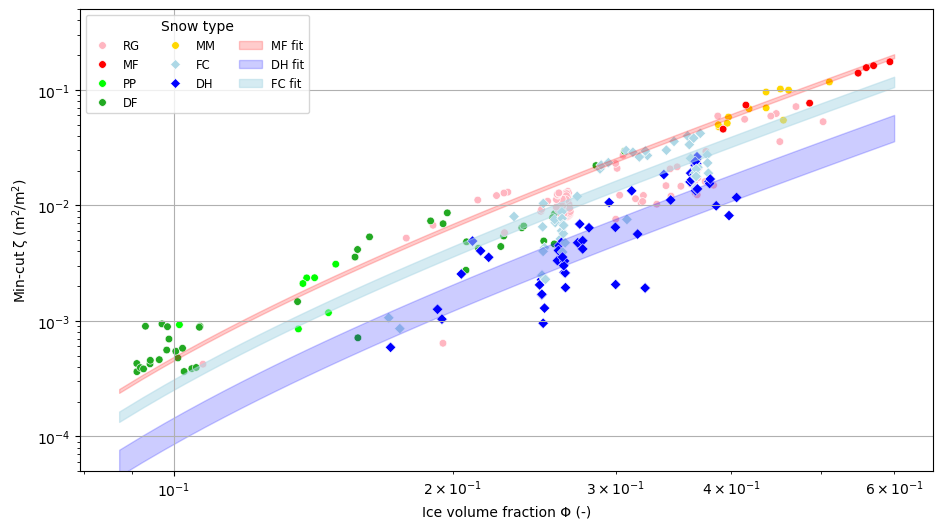

In [8]:
## Density axe
density = np.linspace(80, 550, 100)
phi = density / 917

## Min mincut relation to density and grain types
df_i = df[df["snowTypePrimary "].isin(["PP", "DF", "MF", "MM", "RG", "DF&RG"])]
df_wl = df[df["snowTypePrimary "].isin(["FC", "SH", "DH"])]

classic = "MF"

fig, ax = plt.subplots(figsize=(11, 6))

## All types
sns.scatterplot(ax=ax, data=df_i, x="phi", y="mincut_min", hue="snowTypePrimary ", palette=grain_color, s=30)

## Only PWL grain types
sns.scatterplot(ax=ax, data=df_wl, x="phi", y="mincut_min", hue="snowTypePrimary ", marker="D", palette=grain_color, s=30)
ax.set(yscale="log", xscale="log")

ax.fill_between(
    phi,
    y1=f_mincut_param(density / 917, grain_intervals.loc[classic]["S"][0], grain_intervals.loc[classic]["G"][0]),
    y2=f_mincut_param(density / 917, grain_intervals.loc[classic]["S"][1], grain_intervals.loc[classic]["G"][1]),
    color=grain_color[classic],
    label=classic + " fit",
    alpha=0.2,
)
ax.fill_between(
    phi,
    y1=f_mincut_param(density / 917, grain_intervals.loc["DH"]["S"][0], grain_intervals.loc["DH"]["G"][0]),
    y2=f_mincut_param(density / 917, grain_intervals.loc["DH"]["S"][1], grain_intervals.loc["DH"]["G"][1]),
    color=grain_color["DH"],
    label="DH fit",
    alpha=0.2,
)

ax.fill_between(
    phi,
    y1=f_mincut_param(density / 917, grain_intervals.loc["FC"]["S"][0], grain_intervals.loc["FC"]["G"][0]),
    y2=f_mincut_param(density / 917, grain_intervals.loc["FC"]["S"][1], grain_intervals.loc["FC"]["G"][1]),
    color=grain_color["FC"],
    label="FC fit",
    alpha=0.5,
)
ax.legend()
ax.set_xlabel("Ice volume fraction Φ (-)")
ax.set_ylabel(r"Min-cut ζ (m$^{2}$/m$^{2}$)")
ax.grid(True)
sns.move_legend(ax, loc="best", ncol=3, frameon=True, title="Snow type", fontsize="small")
ax.set_ylim(0.00005, 0.5)

plt.savefig(output_path + "Min_mincut_FINAL_param_vs_density_all_tomography.pdf", dpi=300)


# Comparison with PST (Richter et al., 2019) - WFJ AND WAN7 : Results 2 and 3

In [5]:
data_path = "/home/monteirod/PostDoc_CEN/Wf_param/EXPES/"
output_path = "/home/monteirod/PostDoc_CEN/Wf_param/figures/Article_AC_parameterization/PST_comparison/"

dict_EXPE = {"WAN7": "WAN7_2014_2017_tassement", "WFJ2": "WFJ2_2015_2017_tassement"}

### Load Crocus stratigraphy

In [6]:
show_selection = False

# ## Load PST and Crocus stratigraphy
start_date = {
    "WAN7": {"FC141216": "2014-12-09", "DH151201": "2015-11-26", "FC151231": "2015-12-12", "DH161224": "2016-12-15"},
    "WFJ2": {"DH151201": "2015-11-26", "FC151231": "2015-12-08", "DH161224": "2016-12-15"},
}
end_date = {
    "WAN7": {"FC141216": "2014-12-20T12", "DH151201": "2015-12-05", "FC151231": "2015-12-20", "DH161224": "2016-12-25"},
    "WFJ2": {"DH151201": "2015-12-05", "FC151231": "2015-12-28", "DH161224": "2016-12-25"},
}

# start_date = {
#     "WAN7": {
#         "FC141216": "2014-12-09",
#         #  "SH150124": "2015-01-08",
#         "DH151201": "2015-11-26",
#         "FC151231": "2015-12-12",
#         "DH161224": "2016-12-15",
#         "PP170126": "2017-01-15T18",
#         "PP170218": "2017-02-13",
#     },
#     "WFJ2": {"DH151201": "2015-11-26", "FC151231": "2015-12-08", "DH161224": "2016-12-15"},
# }

# end_date = {
#     "WAN7": {
#         "FC141216": "2014-12-20T12",
#         # "SH150124": "2015-01-24",
#         "DH151201": "2015-12-05",
#         "FC151231": "2015-12-20",
#         "DH161224": "2016-12-25",
#         "PP170126": "2017-01-26",
#         "PP170218": "2017-02-18T18",
#     },
#     "WFJ2": {"DH151201": "2015-12-05", "FC151231": "2015-12-28", "DH161224": "2016-12-25"},
# }

marker_site = {"WAN7": "s", "WFJ2": "D"}
color_layer = {"FC141216": "orange", "SH150124": "purple", "DH151201": "royalblue", "FC151231": "indianred", "DH161224": "darkblue", "PP170218": "darkgreen", "PP170126": "green"}

### Load Crocus stratigraphy + top_depth
ds = {}
for site in start_date:
    ds[site] = xr.load_dataset(glob(data_path + site + "/" + dict_EXPE[site] + "/pro/*")[0]).squeeze()
    ds[site]["Deposition_time"] = ds[site]["SAG_VEG"].time - ds[site]["SAG_VEG"].astype("timedelta64[D]")
    ds[site]["top_depth"] = xr.concat([ds[site]["DSN_T_ISBA"] - ds[site]["SNOWDZ"].isel(snow_layer=slice(0, i)).sum("snow_layer") for i in range(len(ds[site].snow_layer))], dim="snow_layer").where(
        lambda x: x >= 0.0
    )

### Select WL and slab characteristics for each site/layer
ds_layer = {site: {} for site in start_date}
ds_slab = {site: {} for site in start_date}

for site in start_date:
    for layer in start_date[site]:
        dep = ds[site]["Deposition_time"]
        t0 = np.datetime64(start_date[site][layer])
        t1 = np.datetime64(end_date[site][layer])

        mask_wl = (dep > t0) & (dep < t1)
        mask_slab = dep > t1

        # Weak layer: aggregate over snow_layer dimension
        ilayer = ds[site].where(mask_wl)
        ilayer = ilayer.where(ilayer["SNOWTYPE"].isin([0, 1, 2, 4, 8, 9, 10, 11, 13, 14]))
        ilayer["SNOWDZ"] = ilayer["SNOWDZ"].sum("snow_layer")
        ilayer["SNOWTYPE"] = ("time", mode(ilayer["SNOWTYPE"], nan_policy="omit", axis=1)[0])
        ds_layer[site][layer] = ilayer.mean("snow_layer")

        # Restrict to valid timeline
        timeline = ds_layer[site][layer]["RSN_VEG"].dropna("time").time
        tslice = slice(timeline[0], timeline[-1])
        ds_layer[site][layer] = ds_layer[site][layer].sel(time=tslice)

        # Slab and WL kept at full snow_layer resolution for plotting
        ds_slab[site][layer] = ds[site].where(mask_slab).sel(time=tslice)
        ds_wl = ds[site].where(mask_wl).sel(time=tslice)
        mask_wl_t = mask_wl.sel(time=tslice)
        mask_slab_t = mask_slab.sel(time=tslice)

        if show_selection == True:
            ##### PLOT SELECTED SLAB & WL
            fig, (ax_slab, ax_wl) = plt.subplots(1, 2, figsize=(13, 3))

            # Slab
            var_slab = np.where(mask_slab_t, ds_slab[site][layer]["SNOWTYPE"].values, np.nan)
            saisonProfil(ax_slab, ds_slab[site][layer]["SNOWDZ"].fillna(0).values, var_slab, ds_slab[site][layer]["time"].values.astype("datetime64[D]"), colormap="grains", cbar_show=False)
            ax_slab.set_title(f"{site} {layer} — Slab")

            # Weak layer
            var_wl = np.where(mask_wl_t, ds_wl["SNOWTYPE"].values, np.nan)
            saisonProfil(ax_wl, ds_wl["SNOWDZ"].fillna(0).values, var_wl, ds_wl["time"].values.astype("datetime64[D]"), colormap="grains")
            ax_wl.set_title(f"{site} {layer} — Weak Layer")

            plt.tight_layout()
            plt.show()

### Overall stratigraphy of the seasons

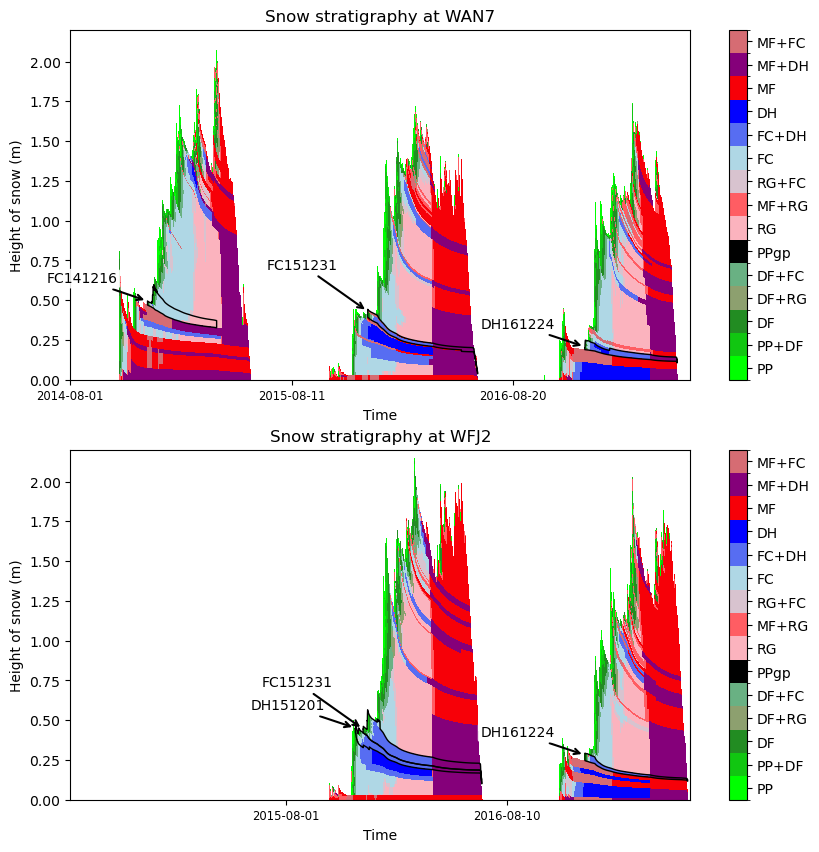

In [ ]:
#######################
########### PLOT ######
#######################

fig, axs = plt.subplots(2, 1, figsize=(10, 10))

for i in range(len(list(ds.keys()))):
    ax = axs[i]
    saisonProfil(
        ax,
        ds[list(ds.keys())[i]]["SNOWDZ"].fillna(0).values,
        ds[list(ds.keys())[i]]["SNOWTYPE"].values,
        ds[list(ds.keys())[i]]["time"].values.astype("datetime64[D]"),
        colormap="grains",
        cbar_show=True,
    )
    if i == 1:
        ax.set_xlim(-1460, 2740)
    else:
        ax.set_xlim(0, 4200)
    ax.set_ylim(0, 2.2)
    ax.set_ylabel("Height of snow (m)")
    ax.set_xlabel("Time")
    ax.set_title("Snow stratigraphy at " + list(dict_EXPE.keys())[i])

    for layer in start_date[list(ds.keys())[i]]:
        dep = ds[list(ds.keys())[i]]["Deposition_time"].values
        t0 = np.datetime64(start_date[list(ds.keys())[i]][layer])
        t1 = np.datetime64(end_date[list(ds.keys())[i]][layer])

        mask_wl = (dep > t0) & (dep < t1)

        # --- CONTOUR ---
        highlight_weak_layer_envelope(ax, ds[list(ds.keys())[i]]["SNOWDZ"].fillna(0).values, mask_wl, label=layer)

        ### annotation
        if i == 1:
            ax.set_xlim(-1460, 2740)
        else:
            ax.set_xlim(0, 4200)

        ax.set_ylim(0, 2.2)
        ax.set_ylabel("Height of snow (m)")
        ax.set_xlabel("Time")
        ax.set_title("Snow stratigraphy at " + list(dict_EXPE.keys())[i])

plt.savefig(output_path + "Stratigraphy_Snowtype_all_site.jpg", dpi=300, bbox_inches="tight")


### Load PST and manual profiles

In [7]:
###########################
## Load PST measurements ##
###########################

## Threshold above which we do not considers PST as valid
tshd_ac = 100

dict_PST = {
    "WAN7": "pst_stab_wan_2015-2016-2017.csv",
    "WFJ2": "pst_stab_wfj_2016-2017.csv",
}

ds_PST = {site: {} for site in start_date}

for site in start_date:
    pst = (
        pd.read_csv(f"/home/monteirod/PostDoc_CEN/DATA/AC_evaluation/Richter2019/stability_tests/{dict_PST[site]}")
        .assign(**{"date [YYYY-MM-DD]": lambda df: pd.to_datetime(df["date [YYYY-MM-DD]"])})
        .set_index("date [YYYY-MM-DD]")
        .to_xarray()
        .rename(
            {
                "date [YYYY-MM-DD]": "time",
                "critical_crack_length [cm]": "ac",
                "dip [cm]": "depth",
            }
        )
    )

    for layer in start_date[site]:
        ds_i = pst.where((pst.layer_id == layer) & (pst.ac < tshd_ac), drop=True)
        ds_PST[site][layer] = ds_i

# Correction spécifique
ds_PST["WAN7"]["FC141216"] = ds_PST["WAN7"]["FC141216"].sel(time=slice("2015-01", "2015-02-13"))
ds_PST["WAN7"]["DH151201"]["depth"] = ("time", [24.0])

###########################
## Load MAN measurements ##
###########################

dict_manprof = {"WAN7": "wan", "WFJ2": "wfj"}


def load_profile(site, time):
    df = pd.read_csv(f"/home/monteirod/PostDoc_CEN/DATA/AC_evaluation/Richter2019/manual_profiles/{dict_manprof[site]}_{time}.txt", sep=" ")

    df.columns = list(df.columns)[1:] + ["None"]
    df = df.iloc[1:]

    df["density"] = df["density"].astype(float).where(lambda x: x > 0, 917)

    df = df.astype(float)
    df["depth"] /= 100
    df["thickness"] /= 100

    ds = df.set_index("depth").to_xarray()
    ds = ds.rename({"thickness": "SNOWDZ", "density": "RSN_VEG"})

    return ds


def process_profile(strati, time):

    dict_conv = {1: "PP", 2: "DF", 3: "RG", 4: "FC", 5: "DH", 6: "SH", 7: "MF", 8: "IF", 9: "FCxr", 10: "MFcr"}
    strati["grain_type1"] = strati["grain_type1"].astype(float)
    strati["grain_type2"] = strati["grain_type2"].astype(float)

    strati["grain_type1"] = strati["grain_type1"].where(strati["grain_type1"] != 0).bfill("depth")
    strati["grain_type2"] = strati["grain_type2"].fillna(0)
    strati["grain_type2"] = strati["grain_type2"].where(strati["grain_type2"] != 0, strati["grain_type1"])

    strati["grain_type"] = ("depth", strati["grain_type1"].values.astype(int))

    strati["grain_type1"] = ("depth", [dict_conv[i] for i in strati["grain_type"].values])
    strati["grain_type2"] = ("depth", [dict_conv[i] for i in strati["grain_type2"].values.astype(int)])

    return strati.expand_dims(time=[pd.to_datetime(time)])


ds_obs = {site: {} for site in start_date}
ds_manual_complete = {site: [] for site in start_date}

for site in start_date:
    for layer in start_date[site]:
        slabs = []

        for t in pd.to_datetime(np.unique(ds_PST[site][layer].time.values)):
            time_str = t.strftime("%Y%m%d")

            strati = load_profile(site, time_str)
            strati = process_profile(strati, t)

            # profondeur WL depuis PST
            top_layer = ds_PST[site][layer]["depth"].sel(time=t).mean() / 100

            idx = int(np.abs(strati.depth - top_layer).argmin())

            slab = strati.isel(depth=slice(0, idx))
            wl = strati.isel(depth=idx)

            slab["S_HSLAB"] = slab["SNOWDZ"].sum("depth")
            slab["S_RHOSLAB"] = (slab["RSN_VEG"] * slab["SNOWDZ"]).sum() / slab["S_HSLAB"]

            slab["S_HWL"] = wl["SNOWDZ"]
            slab["S_RHOWL"] = wl["RSN_VEG"]
            slab["S_ELAYER"] = E_bergfeld_youngs_modulus(wl["RSN_VEG"])
            slab["E_THICKNESS"] = wl["SNOWDZ"]

            for var in ["grain_type", "grain_type1", "grain_type2"]:
                slab[var] = wl[var]

            slabs.append(slab)
            ds_manual_complete[site].append(strati)

        ds_obs[site][layer] = xr.concat(slabs, dim="time").sortby("depth", ascending=False)

    ds_manual_complete[site] = xr.concat(ds_manual_complete[site], dim="time").sortby("depth", ascending=False)

### ADD RHOWL_Crocus for observations
for site in ds_PST:
    for layer in ds_PST[site]:
        ds_obs[site][layer]["S_RHOWL_Crocus"] = ds_layer[site][layer]["RSN_VEG"]


# ## Replace errors in
# ds_manual_complete["WAN7"].sel(time="2016-01-15").dropna(dim="depth", how="all").sel(depth=0.24).isel(time=0)

### Stratigraphy charac : OBS vs MOD

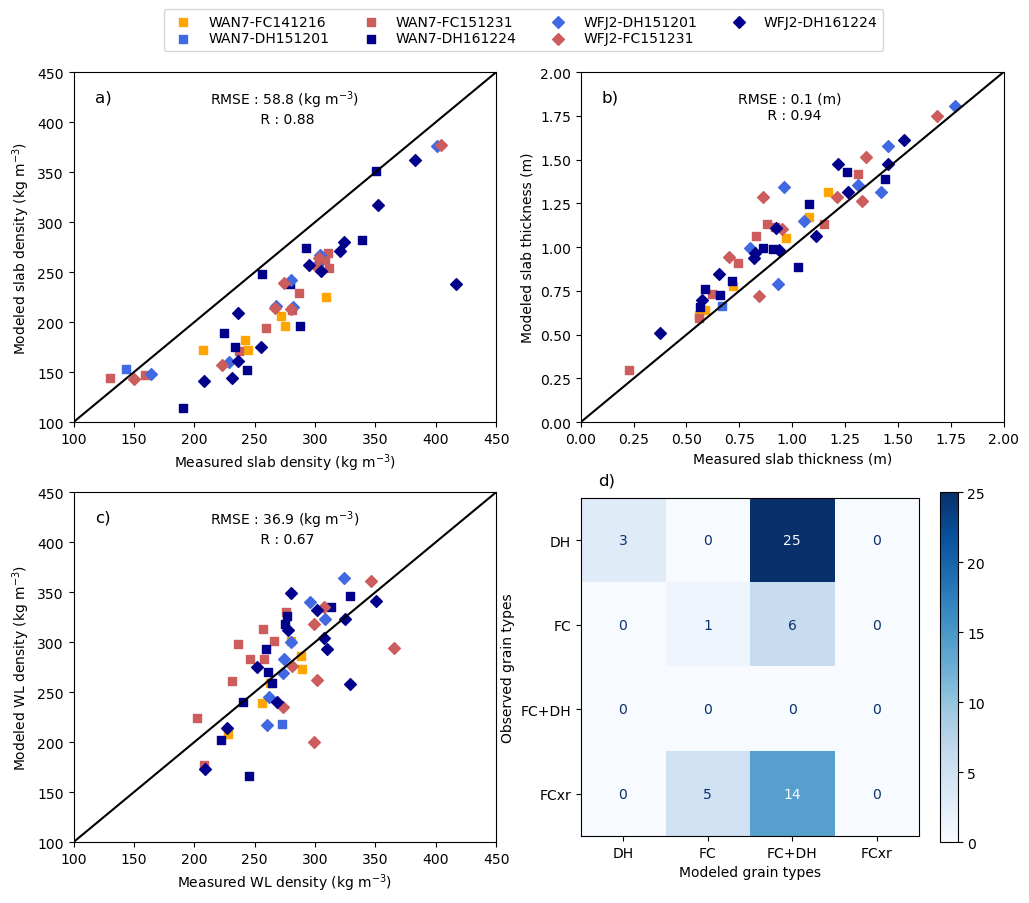

In [64]:
fig = plt.figure(figsize=(12, 10))

#####################################################

ax = fig.add_subplot(2, 2, 1)

ls_mod = []
ls_obs = []
for site in list(start_date.keys()):
    for layer in list(start_date[site].keys()):
        ## Slab density
        mod_slab = ds_layer[site][layer]["S_RHOSLAB"].sel(time=ds_obs[site][layer].time)
        ax.scatter(ds_obs[site][layer]["S_RHOSLAB"], mod_slab, marker=marker_site[site], color=color_layer[layer], label=site + "-" + layer)
        ls_mod.append(mod_slab)
        ls_obs.append(ds_obs[site][layer]["S_RHOSLAB"])

ls_mod, ls_obs = np.concatenate(ls_mod), np.concatenate(ls_obs)
ax.text(
    0.5,
    0.9,
    "RMSE : " + str(np.round(float(np.sqrt(np.mean((ls_mod - ls_obs) ** 2))), 1)) + r" (kg$~$m$^{-3}$)" + "\n R : " + str(np.round(np.corrcoef((ls_obs, ls_mod))[0][1], 2)),
    horizontalalignment="center",
    verticalalignment="center",
    transform=ax.transAxes,
)
ax.set_xlim(100, 450)
ax.set_ylim(100, 450)
ax.plot([0, 1], [0, 1], transform=ax.transAxes, color="k")
ax.set_xlabel(r"Measured slab density (kg$~$m$^{-3}$)")
ax.set_ylabel(r"Modeled slab density (kg$~$m$^{-3}$)")
ax.text(0.05, 0.95, "a)", transform=ax.transAxes, va="top", fontsize="large")

#####################################################

ax = fig.add_subplot(2, 2, 2)
ls_mod = []
ls_obs = []
for site in list(start_date.keys()):
    for layer in list(start_date[site].keys()):
        ## Slab height
        mod_slab = ds_layer[site][layer]["S_HSLAB"].sel(time=ds_obs[site][layer].time, method="nearest")
        ax.scatter(ds_obs[site][layer]["S_HSLAB"], mod_slab, marker=marker_site[site], color=color_layer[layer], label=site + "-" + layer)
        ls_mod.append(mod_slab)
        ls_obs.append(ds_obs[site][layer]["S_HSLAB"])

ls_mod, ls_obs = np.concatenate(ls_mod), np.concatenate(ls_obs)
ax.text(
    0.5,
    0.9,
    "RMSE : " + str(np.round(float(np.sqrt(np.mean((ls_mod - ls_obs) ** 2))), 1)) + " (m) \n R : " + str(np.round(np.corrcoef((ls_obs, ls_mod))[0][1], 2)),
    horizontalalignment="center",
    verticalalignment="center",
    transform=ax.transAxes,
)
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.plot([0, 1], [0, 1], transform=ax.transAxes, color="k")
ax.set_xlabel(r"Measured slab thickness (m)")
ax.set_ylabel(r"Modeled slab thickness (m)")
ax.text(0.05, 0.95, "b)", transform=ax.transAxes, va="top", fontsize="large")

#####################################################
ax = fig.add_subplot(2, 2, 3)
ls_mod = []
ls_obs = []
for site in list(start_date.keys()):
    for layer in list(start_date[site].keys()):
        ## WL density
        mod_wl = ds_layer[site][layer]["RSN_VEG"].sel(time=ds_obs[site][layer].time)
        ax.scatter(ds_obs[site][layer]["S_RHOWL"], mod_wl, marker=marker_site[site], color=color_layer[layer], label=site + "-" + layer)
        ls_mod.append(mod_wl)
        ls_obs.append(ds_obs[site][layer]["S_RHOWL"])

ls_mod, ls_obs = np.concatenate(ls_mod), np.concatenate(ls_obs)
ax.text(
    0.5,
    0.9,
    "RMSE : " + str(np.round(float(np.sqrt(np.mean((ls_mod - ls_obs) ** 2))), 1)) + r" (kg$~$m$^{-3}$)" + "\n R : " + str(np.round(np.corrcoef((ls_obs, ls_mod))[0][1], 2)),
    horizontalalignment="center",
    verticalalignment="center",
    transform=ax.transAxes,
)
ax.set_xlim(100, 450)
ax.set_ylim(100, 450)
ax.plot([0, 1], [0, 1], transform=ax.transAxes, color="k")
ax.set_xlabel(r"Measured WL density (kg$~$m$^{-3}$)")
ax.set_ylabel(r"Modeled WL density (kg$~$m$^{-3}$)")
ax.text(0.05, 0.95, "c)", transform=ax.transAxes, va="top", fontsize="large")


handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, labelspacing=0.2, bbox_to_anchor=(0.5, 0.95))


#####################################################
ax = fig.add_subplot(2, 2, 4)
ls_mod = []
ls_obs = []
for site in list(start_date.keys()):
    for layer in list(start_date[site].keys()):
        ## WL density
        mod_wl = ds_layer[site][layer]["SNOWTYPE"].sel(time=ds_obs[site][layer].time)
        ls_mod.append(mod_wl)
        ls_obs.append(ds_obs[site][layer]["grain_type"])

ls_mod, ls_obs = np.concatenate(ls_mod).astype(int), np.concatenate(ls_obs).astype(int)

dict_conv = {1: "PP", 2: "DF", 3: "RG", 4: "FC", 5: "DH", 6: "SH", 7: "MF", 8: "IF", 9: "FCxr", 10: "MFcr"}
ls_obs = [dict_conv[i] for i in ls_obs]

dict_crocus = {0: "PP", 1: "PP+DF", 2: "DF", 3: "DF+RG", 4: "DF+FC", 5: "PPgp", 6: "RG", 7: "MF+RF", 8: "RG+FC", 9: "FC", 10: "FC+DH", 11: "DH", 12: "MF", 13: "MF+DH", 14: "MF+FC"}
ls_mod = [dict_crocus[i] for i in ls_mod]

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Compute confusion matrix
labels = sorted(list(set(ls_obs) | set(ls_mod)))
cm = confusion_matrix(ls_obs, ls_mod, labels=labels)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d", ax=ax)

# Customize axis titles
ax.set_xlabel("Modeled grain types")
ax.set_ylabel("Observed grain types")

# Plot title
ax.text(0.05, 1.075, "d)", transform=ax.transAxes, va="top", fontsize="large")

fig.savefig(output_path + "Slab_WL_charact_Observed_vs_Crocus.pdf", bbox_inches="tight", dpi=300)


## Comparison Wf and AC using WEAC/Heierli model vs Mincut : Results 2

### Sensitivity of Wf (from WEAC) to weak layer assumptions (APPENDIX)

In [8]:
## Defined parameters to move
RHO_ICE = 917

## Test les différents formulations de E_wl (fixe = 0.15, varying with dataset using Gerling, Bergfeld or scapozza)
E_FORMULATIONS = {
    "fixed (0.15 MPa)": lambda rho: np.full_like(rho, 0.15e9, dtype=float),
    "Scapozza (2004)": lambda rho: 5.07e9 * (rho / RHO_ICE) ** 5.13,
    "Gerling (2017)": lambda rho: 6.0e9 * (rho / RHO_ICE) ** 4.6,
    "Bergfeld (2023)": lambda rho: 6.5e9 * (rho / RHO_ICE) ** 4.4,
}

## Test les différentes assumptions sur h_wl (fixe = 0.03, varying with datasets)
H_ASSUMPTIONS = {
    "fixed (30 mm)": 30e-3,
    "from dataset": None,
}

wf_out, df, df_full = run_wf_sensitivity(
    ds_obs=ds_obs,
    ds_slab=ds_slab,
    ds_layer=ds_layer,
    ds_PST=ds_PST,
    E_FORMULATIONS=E_FORMULATIONS,
    H_ASSUMPTIONS=H_ASSUMPTIONS,
    inclination=0,
    touchdown=False,
)


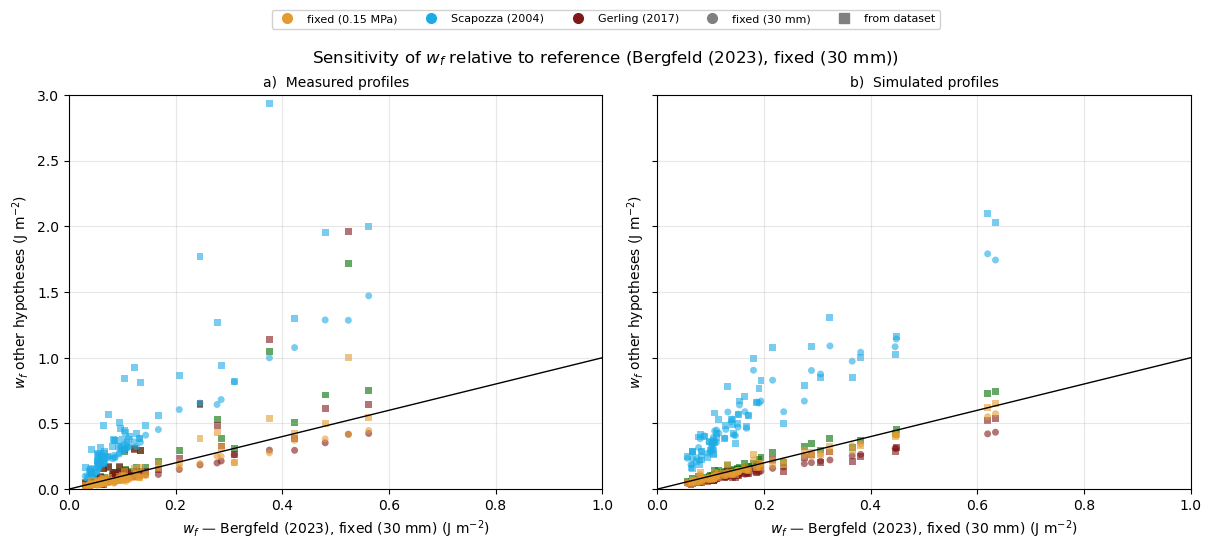

In [9]:
################################################################################
"""Plot Wf for each hypothesis pair vs Wf from reference."""
################################################################################

REF_E = "Bergfeld (2023)"
REF_H = "fixed (30 mm)"

wl_rename = {"OBS": "Measured profiles", "Crocus": "Simulated profiles"}
wl_labels = ["a)", "b)"]
wl_names = df_full["WL_config"].unique()

e_colors = {e: c for e, c in zip(E_FORMULATIONS.keys(), ["#e49b30", "#1dabe6", "#801818", "#006c00"])}
h_markers = {h: m for h, m in zip(H_ASSUMPTIONS.keys(), ["o", "s"])}

fig, axes = plt.subplots(1, len(wl_names), figsize=(6 * len(wl_names), 5), sharey=True, sharex=True, constrained_layout=True)
axes = np.atleast_1d(axes)

for i, (ax, wl_name) in enumerate(zip(axes, wl_names)):
    sub = df_full[df_full["WL_config"] == wl_name]
    ref = sub[(sub["E_formulation"] == REF_E) & (sub["h_assumption"] == REF_H)][["site", "layer", "time", "wf_I_II"]].rename(columns={"wf_I_II": "wf_ref"})

    for (e_name, h_name), grp in sub.groupby(["E_formulation", "h_assumption"]):
        if e_name == REF_E and h_name == REF_H:
            continue

        merged = grp.merge(ref, on=["site", "layer", "time"], how="inner").dropna(subset=["wf_I_II", "wf_ref"])
        if merged.empty:
            continue

        ax.scatter(merged["wf_ref"], merged["wf_I_II"], color=e_colors.get(e_name, "gray"), marker=h_markers.get(h_name, "o"), s=25, alpha=0.6, edgecolors="none", label=f"{e_name} | {h_name}")

    x = np.linspace(0, 1, 100)
    ax.plot(x, x, "k-", lw=1)
    ax.set_title(f"{wl_labels[i]}  {wl_rename.get(wl_name, wl_name)}", fontsize=10)
    ax.set_xlabel(rf"$w_f$ — {REF_E}, {REF_H} (J$~$m$^{{-2}}$)")
    ax.set_ylabel(r"$w_f$ other hypotheses (J$~$m$^{-2}$)")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 3)
    ax.grid(alpha=0.3)

# Legend: color = E formulation, marker = h assumption
legend_handles = [Line2D([0], [0], marker="o", color=c, linestyle="None", markersize=7, label=e) for e, c in e_colors.items() if e != REF_E] + [
    Line2D([0], [0], marker=m, color="gray", linestyle="None", markersize=7, label=h) for h, m in h_markers.items()
]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=len(legend_handles), fontsize=8, framealpha=0.9)

fig.suptitle(rf"Sensitivity of $w_f$ relative to reference ({REF_E}, {REF_H})")
plt.savefig(output_path + "wf_sensitivity_vs_ref.png", dpi=300, bbox_inches="tight")
plt.show()

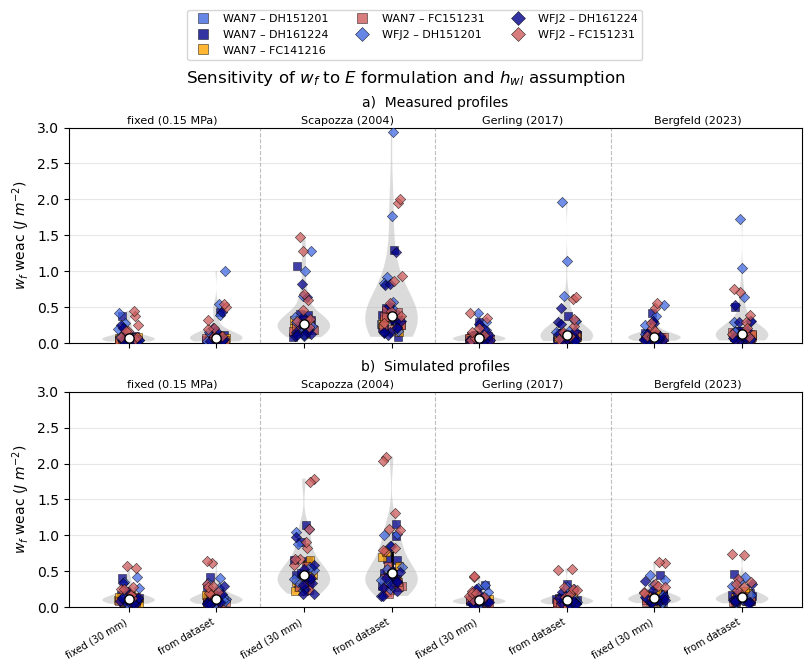

In [11]:
################################################################################
"""Plot Wf distributions for all E/h combinations, one subplot per WL_config."""
################################################################################
wl_rename = {"OBS": "Measured profiles", "Crocus": "Simulated profiles"}
wl_labels = ["a)", "b)"]

wl_names = df_full["WL_config"].unique()
combos = list(itertools.product(E_FORMULATIONS.keys(), H_ASSUMPTIONS.keys()))
x_ticks = np.arange(len(combos))
fig, axes = plt.subplots(len(wl_names), 1, figsize=(8, 6), sharey=True, sharex=True, constrained_layout=True)
axes = np.atleast_1d(axes)
for i, (ax, wl_name) in enumerate(zip(axes, wl_names)):
    sub = df_full[df_full["WL_config"] == wl_name]
    for x_i, (e_name, h_name) in enumerate(combos):
        sub_sel = sub[(sub["E_formulation"] == e_name) & (sub["h_assumption"] == h_name)]
        vals_all = sub_sel["wf_I_II"].dropna().values
        if len(vals_all) == 0:
            continue
        # violin
        vp = ax.violinplot(vals_all, positions=[x_i], widths=0.6, showmedians=False, showextrema=False)
        for b in vp["bodies"]:
            b.set_facecolor("lightgray")
            b.set_alpha(0.8)
        # scatter
        used = set()
        for (site, layer), g in sub_sel.groupby(["site", "layer"]):
            vals = g["wf_I_II"].dropna().values
            if len(vals) == 0:
                continue
            used.add((site, layer))
            jitter = np.random.uniform(-0.12, 0.12, size=len(vals))
            ax.scatter(
                x_i + jitter,
                vals,
                color=color_layer.get(layer, "gray"),
                marker=marker_site.get(site, "o"),
                s=28,
                alpha=0.75,
                edgecolors="black",
                linewidths=0.4,
                zorder=3,
            )
        # median + IQR
        p25, p50, p75 = np.nanpercentile(vals_all, [25, 50, 75])
        ax.vlines(x_i, p25, p75, color="k", linewidth=2)
        ax.scatter(x_i, p50, color="white", edgecolors="k", s=45, zorder=4)
    # vertical separators
    for sep in np.arange(len(H_ASSUMPTIONS), len(combos), len(H_ASSUMPTIONS)) - 0.5:
        ax.axvline(sep, color="gray", ls="--", lw=0.8, alpha=0.5)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([h for _, h in combos], fontsize=7, rotation=30, ha="right")
    # E labels
    for j, e_name in enumerate(E_FORMULATIONS):
        center = j * len(H_ASSUMPTIONS) + (len(H_ASSUMPTIONS) - 1) / 2
        ax.text(center, 1.01, e_name, ha="center", va="bottom", fontsize=8, transform=ax.get_xaxis_transform())
    ax.set_title(f"{wl_labels[i]}  {wl_rename.get(wl_name, wl_name)}", fontsize=10, pad=15)
    ax.set_ylabel(r"$w_f$ weac ($J~m^{-2}$)")
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 3)

handles = []
used_combos = sorted({(s, l) for s, l in used})
handles += [
    Line2D([0], [0], marker=marker_site.get(s, "o"), color=color_layer.get(l, "gray"), linestyle="None", markersize=7, markeredgecolor="black", markeredgewidth=0.4, alpha=0.8, label=f"{s} – {l}")
    for s, l in used_combos
]
fig.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.22, 1.10), fontsize=8, ncol=3)
fig.suptitle(r"Sensitivity of $w_f$ to $E$ formulation and $h_{wl}$ assumption")
plt.savefig(output_path + "wf_sensitivity_E_h_assumptions_distributions.png", dpi=300, bbox_inches="tight")

### Wf against weak layer density : defined fit and coeff (REVIEW)

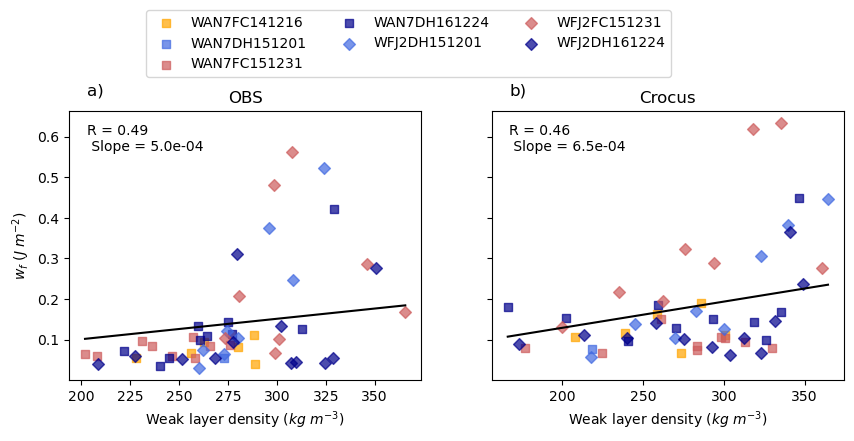

In [12]:
## Model
model = "weac"
## E and h wl taken from data if None (in Pa and m)
E_wl = None
h_wl = 0.030
## Config
inclination = 0

ac_obs, wf_obs = compute_wf_by_inversion(slab=ds_obs, wl=ds_obs, PST=ds_PST, model=model, WL_type="OBS", E_wl=E_wl, h_wl=h_wl, inclination=inclination, touchdown=False)
ac_crocus, wf_crocus = compute_wf_by_inversion(slab=ds_slab, wl=ds_layer, PST=ds_PST, model=model, WL_type="crocus", E_wl=E_wl, h_wl=h_wl, inclination=inclination, touchdown=False)

##############################################################
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

configs = {
    "OBS": (wf_obs, ds_obs, "S_RHOWL"),
    "Crocus": (wf_crocus, ds_layer, "RSN_VEG"),
}

slopes = {}
numbering = ["a", "b", "c", "d", "e", "f", "g"]

i = 0
for ax, (name, (wf_data, ds_data, rho_key)) in zip(axes, configs.items()):
    rho_all, wf_all = [], []

    for site in wf_data:
        for layer in wf_data[site]:
            t = wf_data[site][layer].time

            rho = ds_data[site][layer][rho_key].sel(time=t).values
            wf_vals = wf_data[site][layer]["wf_I_II"].values

            rho_all.append(rho)
            wf_all.append(wf_vals)

            ax.scatter(rho, wf_vals, marker=marker_site[site], color=color_layer[layer], alpha=0.7, label=site + layer)

    rho_all = np.concatenate(rho_all)
    wf_all = np.concatenate(wf_all)

    # correlation
    r = np.corrcoef(rho_all, wf_all)[0, 1]

    # fit
    popt, _ = curve_fit(f_wf_mincut, rho_all, wf_all)
    slopes[name] = popt

    xfit = np.linspace(rho_all.min(), rho_all.max(), 100)
    ax.plot(xfit, f_wf_mincut(popt, xfit), color="k")

    ax.annotate(f"R = {r:.2f} \n Slope = {popt[0]:.1e}", xy=(0.05, 0.85), xycoords="axes fraction")

    ax.text(0.05, 1.1, numbering[i] + ")", transform=ax.transAxes, va="top", fontsize="large")
    ax.set_title(name)
    ax.set_xlabel(r"Weak layer density ($kg~m^{-3}$)")

    i = +1

axes[0].set_ylabel(r"$w_f$ ($J~m^{-2}$)")

plt.legend(
    bbox_to_anchor=(-1.0, 1.4),
    ncol=3,
    loc="upper left",
)

## Saved slope
popt_rhowl_obs = slopes["OBS"]
popt_rhowl_crocus = slopes["Crocus"]

# plt.savefig(output_path + "Fit_Wf_vs_RHOWL_OBS_and_Crocus.pdf", dpi=300, bbox_inches="tight")


### Ratio of estimated Wf (APPENDIX)

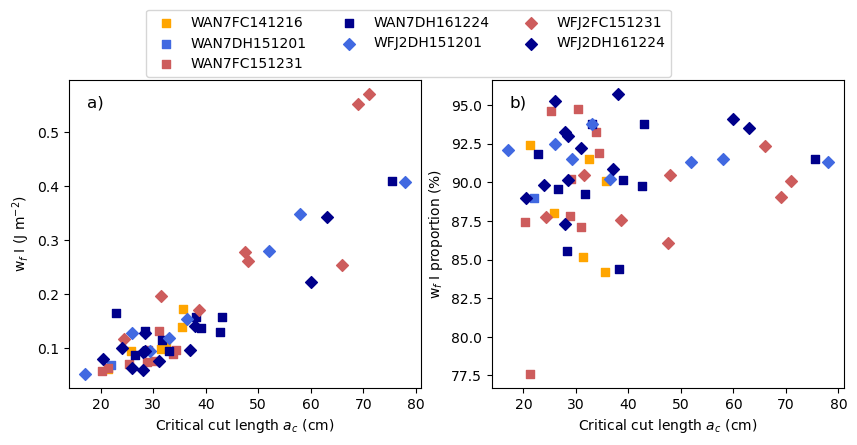

In [13]:
fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(1, 2, 1)

var = "wf_I"

for site in wf_crocus:
    for layer in wf_crocus[site]:
        plt.scatter(
            ac_crocus[site][layer] / 10,
            wf_crocus[site][layer][var],
            marker=marker_site[site],
            color=color_layer[layer],
            label=site + layer,
        )
plt.xlabel(r"Critical cut length $a_c$ (cm)")
plt.ylabel(r"w$_f$ I (J$~$m$^{-2}$)")
ax.text(0.05, 0.95, "a)", transform=ax.transAxes, va="top", fontsize="large")

ax = fig.add_subplot(1, 2, 2)
for site in wf_crocus:
    for layer in wf_crocus[site]:
        plt.scatter(
            ac_crocus[site][layer] / 10,
            wf_crocus[site][layer][var] / wf_crocus[site][layer]["wf_I_II"] * 100,
            marker=marker_site[site],
            color=color_layer[layer],
            label=site + layer,
        )
plt.xlabel(r"Critical cut length $a_c$ (cm)")
plt.ylabel(r"w$_f$ I proportion (%)")
ax.text(0.05, 0.95, "b)", transform=ax.transAxes, va="top", fontsize="large")

plt.legend(bbox_to_anchor=(-1.0, 1.25), ncol=3, loc="upper left")
plt.savefig(output_path + "Wf_vs_ac_RATIO_Wf_I.pdf", dpi=300, bbox_inches="tight")


### Parameterize Wf Using manual and crocus profiles

In [8]:
importlib.reload(utils_funcs_Wf_param)


## Defined parameters to move
RHO_ICE = 917

## Test les différents formulations de E_wl (fixe = ???, varying with dataset using Gerling, Bergfeld or scapozza)
E_FORMULATIONS = {
    # "fixed (0.15 MPa)": lambda rho: np.full_like(rho, 0.25e9, dtype=float),
    # "Scapozza (2004)": lambda rho: 5.07e9 * (rho / RHO_ICE) ** 5.13,
    # "Gerling (2017)": lambda rho: 6.0e9 * (rho / RHO_ICE) ** 4.6,
    "Bergfeld (2023)": lambda rho: 6.5e9 * (rho / RHO_ICE) ** 4.4,
}

## Test les différentes assumptions sur h_wl (fixe = 0.03, varying with datasets)
H_ASSUMPTIONS = {
    "fixed (30 mm)": 30e-3,
    # "from dataset": None,
}

touchdown = False
model = "weac"
inclination = 0

wf_out, df, df_full = run_wf_sensitivity(
    ds_obs=ds_obs,
    ds_slab=ds_slab,
    ds_layer=ds_layer,
    ds_PST=ds_PST,
    E_FORMULATIONS=E_FORMULATIONS,
    H_ASSUMPTIONS=H_ASSUMPTIONS,
    inclination=inclination,
    touchdown=touchdown,
)

var_wf = "wf_I_II"
s0, l0 = next(iter(start_date)), next(iter(next(iter(start_date.values()))))
param_keys = [k.replace(f"{var_wf}__", "") for k in wf_out["OBS"][s0][l0].data_vars if k.startswith(f"{var_wf}__")]


def build_wf_dict(wf_out_wl, pk):
    return {s: {l: wf_out_wl[s][l][f"{var_wf}__{pk}"] for l in start_date[s]} for s in start_date}


def wf_stats(wf_out_wl):
    med, qlo, qhi = ({s: {} for s in start_date} for _ in range(3))
    for s in start_date:
        for l in start_date[s]:
            ds = wf_out_wl[s][l]
            keys = [k for k in ds.data_vars if k.startswith(f"{var_wf}__")]
            arr = np.stack([ds[k].values for k in keys], axis=1)
            times = ds[keys[0]].time.values
            med[s][l] = xr.DataArray(np.nanmedian(arr, axis=1), dims="time", coords={"time": times})
            qlo[s][l] = np.nanpercentile(arr, 10, axis=1)
            qhi[s][l] = np.nanpercentile(arr, 90, axis=1)
    return med, qlo, qhi


wf_obs_med, wf_obs_qlo, wf_obs_qhi = wf_stats(wf_out["OBS"])
wf_crocus_med, wf_crocus_qlo, wf_crocus_qhi = wf_stats(wf_out["Crocus"])

WL_charact_OBS = WL_charact_crocus = None
all_popt_obs, all_r2_obs, all_popt_crocus, all_r2_crocus = [], [], [], []

for pk in param_keys:
    charact_o, popt_o, r2_o = compute_mincut_and_fit_wf(wf=build_wf_dict(wf_out["OBS"], pk), wl=ds_obs, WL_type="OBS", wf_var=var_wf, grain_intervals=grain_intervals)
    charact_c, popt_c, r2_c = compute_mincut_and_fit_wf(wf=build_wf_dict(wf_out["Crocus"], pk), wl=ds_layer, WL_type="crocus", wf_var=var_wf, grain_intervals=grain_intervals)
    if WL_charact_OBS is None:
        WL_charact_OBS, WL_charact_crocus = charact_o, charact_c
    all_popt_obs.extend([popt_o["lower"][0], popt_o["upper"][0]])
    all_r2_obs.extend([r2_o["lower"], r2_o["upper"]])
    all_popt_crocus.append(popt_c[0])
    all_r2_crocus.append(r2_c)

popt_obs_range = {"lower": min(all_popt_obs), "upper": max(all_popt_obs)}
r2_obs_range = {"lower": min(all_r2_obs), "upper": max(all_r2_obs)}
popt_crocus_range = {"lower": min(all_popt_crocus), "upper": max(all_popt_crocus)}
r2_crocus_range = {"lower": min(all_r2_crocus), "upper": max(all_r2_crocus)}

# ac_obs pour la série temporelle (formulation de référence)
e_name_ref, e_func_ref = next(iter(E_FORMULATIONS.items()))
h_name_ref, h_val_ref = next(iter(H_ASSUMPTIONS.items()))
for s in start_date:
    for l in start_date[s]:
        rho_da = ds_obs[s][l]["S_RHOWL"]
        ds_obs[s][l]["S_ELAYER"] = xr.DataArray(e_func_ref(rho_da.values), dims=rho_da.dims, coords=rho_da.coords)

ac_obs, _ = compute_wf_by_inversion(
    slab=ds_obs,
    wl=ds_obs,
    PST=ds_PST,
    model=model,
    WL_type="OBS",
    E_wl=None,
    h_wl=h_val_ref,
    e_method_slab=E_METHOD_MAP[e_name_ref],
    inclination=inclination,
    touchdown=touchdown,
)

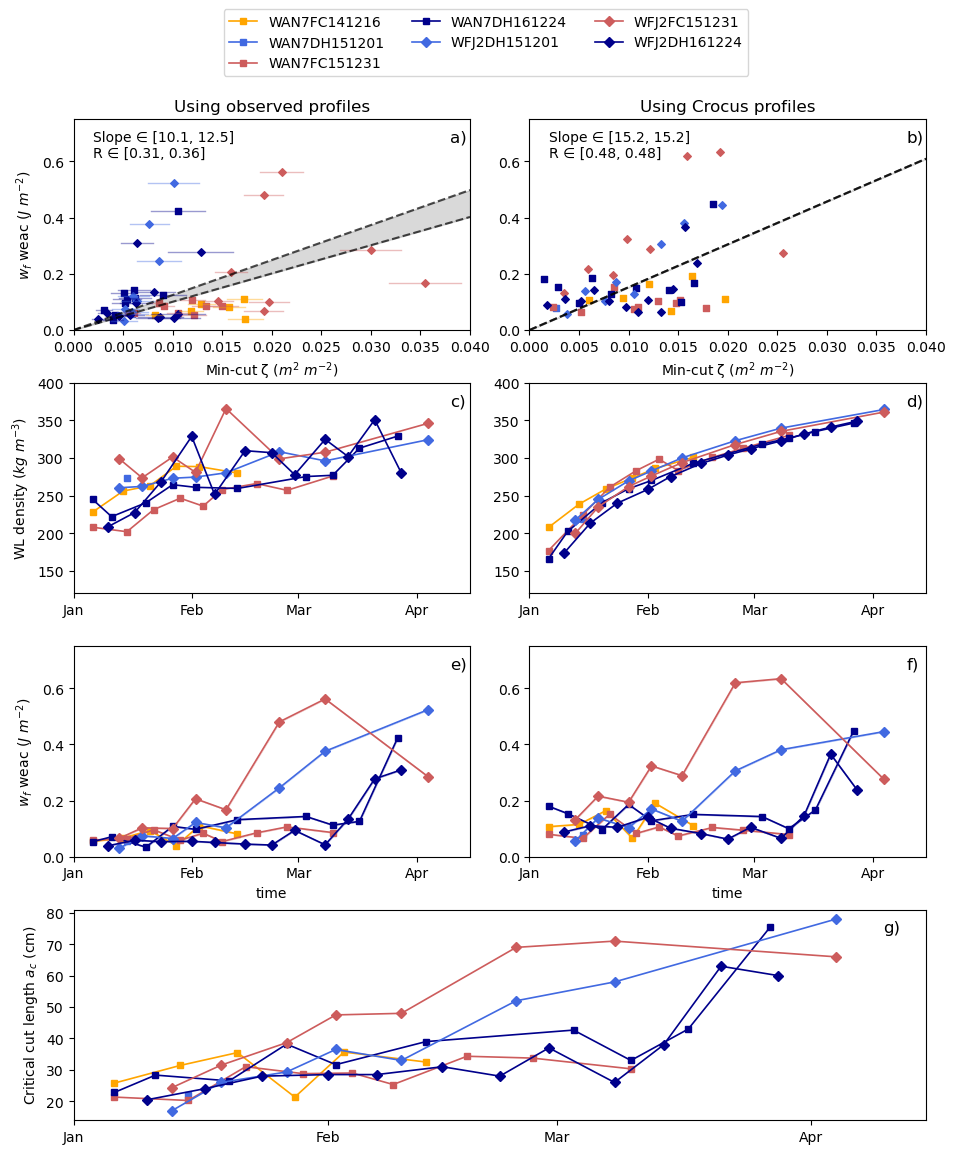

In [13]:
def compute_mc_interval(WL_layer, grain_interval):
    mc_min = f_mincut_param(WL_layer["S_RHOWL"] / 917, grain_interval["S"][0], grain_interval["G"][0])
    mc_max = f_mincut_param(WL_layer["S_RHOWL"] / 917, grain_interval["S"][1], grain_interval["G"][1])
    return mc_min, mc_max


def plot_mc_interval(ax, mc_min, mc_max, wf, color):
    for i in range(len(wf)):
        ax.plot([mc_min[i], mc_max[i]], [wf[i], wf[i]], color=color, alpha=0.4, linewidth=1)


def iter_layers(start_date):
    for site in start_date:
        for layer in start_date[site]:
            yield site, layer


import matplotlib.dates as mdates

REF_YEAR = 2000  # fictional reference year for the season


def to_season_date(t):
    """Map any date to a fixed season (REF_YEAR/REF_YEAR+1), keeping month and day."""
    dt = pd.Timestamp(t)
    year = REF_YEAR if dt.month >= 10 else REF_YEAR + 1
    return dt.replace(year=year)


def get_season_times(da):
    """Extract time coordinate from DataArray and convert to season dates."""
    return np.array([to_season_date(t) for t in pd.to_datetime(da.time.values)])


def format_season_axis(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.set_xlim(pd.Timestamp(f"{REF_YEAR + 1}-01-01"), pd.Timestamp(f"{REF_YEAR + 1}-04-15"))


def plot_timeseries(ax, data, qlo=None, qhi=None, ylabel=None):
    for site, layer in iter_layers(start_date):
        da = data[site][layer]
        x = get_season_times(da)
        y = da.values

        ax.plot(x, y, marker=marker_site[site], color=color_layer[layer], label=site + layer, ms=5, lw=1.2)

        if qlo is not None and qhi is not None:
            ax.fill_between(x, np.asarray(qlo[site][layer]), np.asarray(qhi[site][layer]), color=color_layer[layer], alpha=0.2)

    format_season_axis(ax)
    if ylabel:
        ax.set_ylabel(ylabel)


fig = plt.figure(figsize=(11, 13))
wf_lim = 0.75
mincut_lim = 0.04
xfit = np.linspace(0, mincut_lim, 200)

## OBS
ax = fig.add_subplot(4, 2, 1)
for site, layer in iter_layers(start_date):
    grain_key = layer[:2]
    mc_min, mc_max = compute_mc_interval(WL_charact_OBS[site][layer], grain_intervals.loc[grain_key])
    wf_med = np.asarray(wf_obs_med[site][layer])
    mc_mid = 0.5 * (mc_min + mc_max)
    yerr = [wf_med - wf_obs_qlo[site][layer], wf_obs_qhi[site][layer] - wf_med]
    ax.errorbar(mc_mid, wf_med, yerr=yerr, fmt="none", color=color_layer[layer], alpha=0.4, linewidth=1)
    ax.scatter(mc_mid, wf_med, marker=marker_site[site], color=color_layer[layer], s=15)
    plot_mc_interval(ax, mc_min, mc_max, wf_med, color_layer[layer])

ax.plot(xfit, f_wf_mincut(xfit, popt_obs_range["lower"]), "k--", alpha=0.7)
ax.plot(xfit, f_wf_mincut(xfit, popt_obs_range["upper"]), "k--", alpha=0.7)
ax.fill_between(xfit, f_wf_mincut(xfit, popt_obs_range["lower"]), f_wf_mincut(xfit, popt_obs_range["upper"]), color="k", alpha=0.15)
ax.text(0.05, 0.95, f"Slope ∈ [{popt_obs_range['lower']:.1f}, {popt_obs_range['upper']:.1f}]\nR ∈ [{r2_obs_range['lower']:.2f}, {r2_obs_range['upper']:.2f}]", transform=ax.transAxes, va="top")
ax.set(xlabel=r"Min-cut ζ ($m^{2}~m^{-2}$)", ylabel=r"$w_{f}$ " + f"{model}" + r" ($J~m^{-2}$)", xlim=(0, mincut_lim), ylim=(0, wf_lim), title="Using observed profiles")
ax.text(0.95, 0.95, "a)", transform=ax.transAxes, va="top", fontsize="large")

## CROCUS
ax = fig.add_subplot(4, 2, 2)
for site, layer in iter_layers(start_date):
    mc = f_mincut_param(WL_charact_crocus[site][layer]["S_RHOWL"] / 917, WL_charact_crocus[site][layer]["SNOWSPHER"], WL_charact_crocus[site][layer]["SNOWSSA"])
    wf_med = np.asarray(wf_crocus_med[site][layer])
    yerr = [wf_med - wf_crocus_qlo[site][layer], wf_crocus_qhi[site][layer] - wf_med]
    ax.errorbar(mc, wf_med, yerr=yerr, fmt="none", color=color_layer[layer], alpha=0.4, linewidth=1)
    ax.scatter(mc, wf_med, marker=marker_site[site], color=color_layer[layer], s=15)

ax.plot(xfit, f_wf_mincut(xfit, popt_crocus_range["lower"]), "k--", alpha=0.7)
ax.plot(xfit, f_wf_mincut(xfit, popt_crocus_range["upper"]), "k--", alpha=0.7)
ax.fill_between(xfit, f_wf_mincut(xfit, popt_crocus_range["lower"]), f_wf_mincut(xfit, popt_crocus_range["upper"]), color="k", alpha=0.15)
ax.text(
    0.05, 0.95, f"Slope ∈ [{popt_crocus_range['lower']:.1f}, {popt_crocus_range['upper']:.1f}]\nR ∈ [{r2_crocus_range['lower']:.2f}, {r2_crocus_range['upper']:.2f}]", transform=ax.transAxes, va="top"
)
ax.set(xlabel=(r"Min-cut ζ ($m^{2}~m^{-2}$)"), xlim=(0, mincut_lim), ylim=(0, wf_lim), title="Using Crocus profiles")
ax.text(0.95, 0.95, "b)", transform=ax.transAxes, va="top", fontsize="large")

## WL density — OBS
ax = fig.add_subplot(4, 2, 3)
for site, layer in iter_layers(start_date):
    da = WL_charact_OBS[site][layer]["S_RHOWL"]
    x = get_season_times(da)
    ax.plot(x, da.values, marker=marker_site[site], color=color_layer[layer], label=site + layer, ms=5, lw=1.2)
format_season_axis(ax)
ax.set_ylabel(r"WL density ($kg~m^{-3}$)")
ax.set_ylim(120, 400)
ax.text(0.95, 0.95, "c)", transform=ax.transAxes, va="top", fontsize="large")

## WL density — Crocus
ax = fig.add_subplot(4, 2, 4)
for site, layer in iter_layers(start_date):
    da = WL_charact_crocus[site][layer]["S_RHOWL"]
    x = get_season_times(da)
    ax.plot(x, da.values, marker=marker_site[site], color=color_layer[layer], ms=5, lw=1.2)
format_season_axis(ax)
ax.set_ylim(120, 400)
ax.text(0.95, 0.95, "d)", transform=ax.transAxes, va="top", fontsize="large")

## Wf timeseries
ax = fig.add_subplot(4, 2, 5)
plot_timeseries(ax, wf_obs_med, qlo=wf_obs_qlo, qhi=wf_obs_qhi, ylabel=r"$w_{f}$ " + f"{model}" + r" ($J~m^{-2}$)")
ax.set_ylim(0, wf_lim)
ax.text(0.95, 0.95, "e)", transform=ax.transAxes, va="top", fontsize="large")
ax.set_xlabel("time")

ax = fig.add_subplot(4, 2, 6)
plot_timeseries(ax, wf_crocus_med, qlo=wf_crocus_qlo, qhi=wf_crocus_qhi)
ax.set_ylim(0, wf_lim)
ax.text(0.95, 0.95, "f)", transform=ax.transAxes, va="top", fontsize="large")
ax.set_xlabel("time")

## AC timeseries
ax = fig.add_subplot(4, 1, 4)
for site, layer in iter_layers(start_date):
    da = ac_obs[site][layer]
    x = get_season_times(da)
    ax.plot(x, da.values / 10, marker=marker_site[site], color=color_layer[layer], label=site + layer, ms=5, lw=1.2)
format_season_axis(ax)
ax.set_ylabel(r"Critical cut length $a_c$ (cm)")
ax.text(0.95, 0.95, "g)", transform=ax.transAxes, va="top", fontsize="large")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.97))
plt.subplots_adjust(wspace=0.15, hspace=0.25)

plt.savefig(output_path + "Wf_Mincut_Crocus_and_OBS_profiles_WL_weac.pdf", dpi=300, bbox_inches="tight")


In [15]:
def compute_mincut_fit_leave_one_out(wf, wl, grain_intervals, WL_type="OBS", wf_var="wf_I_II"):
    all_pairs = [(site, layer) for site in wf for layer in wf[site]]
    # print(all_pairs)
    records = []

    for excl_site, excl_layer in all_pairs:
        # Build reduced dicts excluding (excl_site, excl_layer)
        wf_sub = {site: {layer: wf[site][layer] for layer in wf[site] if (site, layer) != (excl_site, excl_layer)} for site in wf}
        wl_sub = {site: {layer: wl[site][layer] for layer in wl[site] if (site, layer) != (excl_site, excl_layer)} for site in wl}

        _, popt, r2 = compute_mincut_and_fit_wf(
            wf=wf_sub,
            wl=wl_sub,
            grain_intervals=grain_intervals,
            WL_type=WL_type,
            wf_var=wf_var,
        )

        ## Expand dataframe using resulting slope
        row = {"excluded_site": excl_site, "excluded_layer": excl_layer}
        if WL_type == "OBS":
            row.update(
                {
                    "popt_lower": float(popt["lower"]),
                    "popt_upper": float(popt["upper"]),
                    "r2_lower": float(r2["lower"]),
                    "r2_upper": float(r2["upper"]),
                }
            )
        else:
            row.update({"popt": float(popt), "r2": float(r2)})

        records.append(row)

    return pd.DataFrame(records)


df_loo_obs = compute_mincut_fit_leave_one_out(wf=wf_obs_med, wl=ds_obs, grain_intervals=grain_intervals, WL_type="OBS")
df_loo_crocus = compute_mincut_fit_leave_one_out(wf=wf_crocus_med, wl=ds_layer, grain_intervals=grain_intervals, WL_type="crocus")

### Statistique of LOO for Crocus and OBS slopes and R
med_c = round(df_loo_crocus["popt"].median(), 2)
q10_c = round(df_loo_crocus["popt"].quantile(0.1), 2)
q90_c = round(df_loo_crocus["popt"].quantile(0.9), 2)
rmin_c = round(df_loo_crocus["r2"].min(), 2)
rmax_c = round(df_loo_crocus["r2"].max(), 2)

print(f"Median slope Crocus : {med_c} [q10: {q10_c}, q90: {q90_c}] | R Crocus : min {rmin_c} – max {rmax_c}")

# --------------------------------------------------------------
popt_mean = (df_loo_obs["popt_upper"] + df_loo_obs["popt_lower"]) / 2
med_o = round(popt_mean.median(), 2)
q10_o = round(popt_mean.quantile(0.1), 2)
q90_o = round(popt_mean.quantile(0.9), 2)
rmin_o = round(df_loo_obs["r2_lower"].min(), 2)
rmax_o = round(df_loo_obs["r2_upper"].max(), 2)

print(f"Median slope OBS   : {med_o} [q10: {q10_o}, q90: {q90_o}] | R OBS   : min {rmin_o} – max {rmax_o}")

Median slope Crocus : 15.28 [q10: 13.74, q90: 16.5] | R Crocus : min 0.41 – max 0.53
Median slope OBS   : 11.26 [q10: 10.43, q90: 12.2] | R OBS   : min 0.04 – max 0.43


### AC OBS vs. MOD : Weac and Heierli

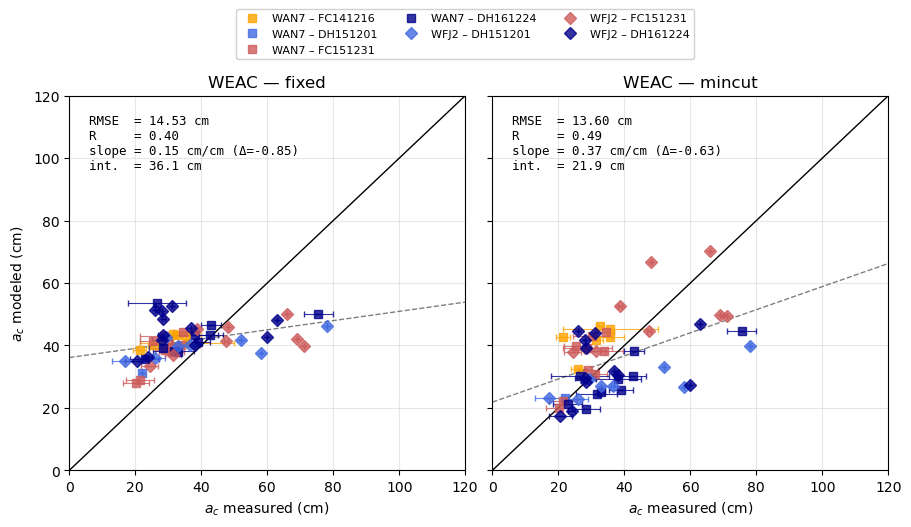

In [22]:
def plot_ac_vs_obs(ds_model, mode="median", param_key=None, title=""):
    def rmse(o, m):
        mask = np.isfinite(o) & np.isfinite(m)
        return np.sqrt(np.mean((o[mask] - m[mask]) ** 2))

    def corr(o, m):
        mask = np.isfinite(o) & np.isfinite(m)
        return np.corrcoef(o[mask], m[mask])[0, 1]

    def slope(o, m):
        """Slope of AC_mod ~ AC_obs linear regression (intercept free). Deviation from 1 = bias."""
        mask = np.isfinite(o) & np.isfinite(m)
        s, intercept = np.polyfit(o[mask], m[mask], 1)
        return float(s), float(intercept)

    wf_modes = list(ds_model.keys())
    fig, axes = plt.subplots(1, len(wf_modes), figsize=(4.5 * len(wf_modes), 4.5), sharey=True, sharex=True, constrained_layout=True)
    axes = np.atleast_1d(axes)
    legend_handles = {}

    for ax, wf_mode in zip(axes, wf_modes):
        obs_all, mod_all = [], []

        for site in ds_model[wf_mode]:
            for layer in ds_model[wf_mode][site]:
                ds = ds_model[wf_mode][site][layer]
                ac_obs = ds_PST[site][layer]["ac"].groupby("time").mean()
                ac_std = ds_PST[site][layer]["ac"].groupby("time").std()
                ds = ds.sel(time=ac_obs.time)

                color = color_layer.get(layer, "gray")
                marker = marker_site.get(site, "o")
                label = f"{site} – {layer}"

                if mode == "median":
                    ac_mod = ds["ac_median"].values
                    yerr = np.vstack([ac_mod - ds["ac_q_low"].values, ds["ac_q_high"].values - ac_mod])
                else:
                    ac_mod = ds["ac"].sel(param=param_key).values
                    yerr = None

                h = ax.errorbar(ac_obs, ac_mod, xerr=ac_std, yerr=yerr, fmt=marker, color=color, ms=6, alpha=0.8, ecolor=color, elinewidth=0.8, capsize=2, label=label)
                if label not in legend_handles:
                    legend_handles[label] = h[0]

                obs_all.append(ac_obs.values)
                mod_all.append(ac_mod)

        obs_all = np.concatenate(obs_all)
        mod_all = np.concatenate(mod_all)

        # s = slope(obs_all, mod_all)
        s, intercept = slope(obs_all, mod_all)
        x = np.linspace(0, 120, 200)

        ax.plot(x, x, "k-", lw=1)
        ax.plot(x, s * x + intercept, "k--", lw=1, alpha=0.5)
        ax.text(
            0.05,
            0.95,
            f"RMSE  = {rmse(obs_all, mod_all):.2f} cm \nR     = {corr(obs_all, mod_all):.2f}\nslope = {s:.2f} cm/cm (Δ={s - 1:+.2f})\nint.  = {intercept:.1f} cm",
            transform=ax.transAxes,
            va="top",
            fontsize=9,
            family="monospace",
        )
        ax.set(xlim=(0, 120), ylim=(0, 120), xlabel=r"$a_c$ measured (cm)", ylabel=r"$a_c$ modeled (cm)" if ax == axes[0] else "", title=f"{title} — {wf_mode}")
        ax.grid(alpha=0.3)

    fig.legend(handles=list(legend_handles.values()), labels=list(legend_handles.keys()), loc="upper left", bbox_to_anchor=(0.25, 1.15), fontsize=8, ncol=3, framealpha=0.9)

    return fig


# ─────────────────────────────────────────────

WL = "OBS"  # "crocus" | "OBS"
WF_MODES = ["fixed", "mincut"]  # subset or all
WF_FIXED = 0.15
inclination = 0
touchdown = False

E_FORMULATIONS = {
    # "fixed (0.15 MPa)": lambda rho: np.full_like(rho, 0.15e6, dtype=float),
    # "Gerling (2017)": lambda rho: 6.0e9 * (rho / RHO_ICE) ** 4.6,
    # "Scapozza (2004)": lambda rho: 5.07e9 * (rho / RHO_ICE) ** 5.13,
    "Bergfeld (2023)": lambda rho: 6.5e9 * (rho / RHO_ICE) ** 4.4,
}

H_ASSUMPTIONS = {
    "fixed (30 mm)": 30e-3,
    # "from dataset": None,
}

WL_CFG = {
    "OBS": {"wl": ds_obs, "slab": ds_obs, "dim": "depth", "rho_key": "S_RHOWL", "h_key": "E_THICKNESS"},
    # "OBS": {"wl": ds_obs, "slab": ds_obs, "dim": "depth", "rho_key": "S_RHOWL_Crocus", "h_key": "E_THICKNESS"},
    "crocus": {"wl": ds_layer, "slab": ds_slab, "dim": "snow_layer", "rho_key": "RSN_VEG", "h_key": "SNOWDZ"},
}

## Stored all necessary linear fit slope
popt_gaume_crocus = 3.0
popt_gaume_obs = 2.5
popt_rhowl_obs = 0.00050
popt_rhowl_crocus = 0.00065
##
popt = {}
popt["popt_rhowl_crocus"] = popt_rhowl_crocus
popt["popt_crocus"] = [popt_crocus_range["lower"], popt_crocus_range["upper"]]
popt["popt_rhowl_obs"] = popt_rhowl_obs
popt["popt_obs"] = [popt_obs_range["lower"], popt_obs_range["upper"]]
popt["popt_gaume_crocus"] = popt_gaume_crocus
popt["popt_gaume_obs"] = popt_gaume_obs


ds_ac_weac, ds_ac_heierli = compute_ac_sensitivity(
    WL=WL,
    PST=ds_PST,
    WL_CFG=WL_CFG,
    WF_MODES=WF_MODES,
    popt=popt,
    E_FORMULATIONS=E_FORMULATIONS,
    H_ASSUMPTIONS=H_ASSUMPTIONS,
    WF_FIXED=WF_FIXED,
    grain_intervals=grain_intervals,
    inclination=inclination,
    touchdown=touchdown,
)

fig = plot_ac_vs_obs(ds_ac_weac, mode="median", title="WEAC")
plt.savefig(output_path + "Modeled_vs_measured_AC_" + WL + "_WEAC.pdf", dpi=300, bbox_inches="tight")
# plt.savefig(output_path + "Modeled_vs_measured_AC_" + WL + "_RHOWL_crocus_WEAC.pdf", dpi=300)

# plot_ac_vs_obs(ds_ac_heierli, mode="median", title="Heierli")
# plt.savefig("Modeled_vs_measured_AC_" + WL + "_HEIERLI.pdf", dpi=300)


## AC time series of WL (Crocus only) : Results 3.1

In [23]:
start_date = {
    "WAN7": {
        "FC141216": "2014-12-09",
        # "DH151201": "2015-11-26",
        "FC151231": "2015-12-12",
        "DH161224": "2016-12-15",
    },
    "WFJ2": {"DH151201": "2015-11-26", "FC151231": "2015-12-08", "DH161224": "2016-12-15"},
}

end_date = {
    "WAN7": {
        "FC141216": "2014-12-20T12",
        # "DH151201": "2015-12-05",
        "FC151231": "2015-12-20",
        "DH161224": "2016-12-25",
    },
    "WFJ2": {"DH151201": "2015-12-05", "FC151231": "2015-12-28", "DH161224": "2016-12-25"},
}


In [32]:
WL_TYPE = "crocus"
WF_MODES = ["fixed", "mincut"]  # liste des modes à calculer
WF_FIXED = 0.15
inclination = 0
touchdown = False
E_FORMULATION = ("Bergfeld (2023)", lambda rho: 6.5e9 * (rho / RHO_ICE) ** 4.4)
H_ASSUMPTION = ("fixed", 30e-3)

e_name, e_func = E_FORMULATION
h_name, h_val = H_ASSUMPTION

POPT_MAP = {
    "density": float(popt_rhowl_crocus),
    "Strength_Gaume": float(popt_gaume_crocus),
}


def get_popt(mode):
    return POPT_MAP.get(mode, float(np.mean([popt_crocus_range["lower"], popt_crocus_range["upper"]])))


def get_wf(rho_wl, sph, ssa, mode, popt):
    if mode == "fixed":
        return WF_FIXED
    if mode == "density":
        return float(f_wf_mincut(rho_wl, popt))
    return float(f_wf_mincut(f_mincut_param(rho_wl / 917, sph, ssa), popt))


def invert_ac_weac(rho, dz, rho_wl, h, E, wf_target, e_method_slab, bounds=(0.01, 1500), inclination=inclination, touchdown=touchdown):
    def f(ac):
        _, G = compute_wf_weac(
            rho=rho,
            dz=dz * 1000,
            rho_wl=rho_wl,
            ac=[ac],
            E_method_slab=e_method_slab,
            h_wl=h * 1000,
            E_wl=E / 1e6,
            inclination=inclination,
            touchdown=touchdown,
        )
        return float(G[0, 0]) - wf_target

    try:
        lo, hi = bounds
        return np.nan if f(lo) * f(hi) > 0 else brentq(f, lo, hi) / 10
    except Exception:
        return np.nan


results = {}

for WF_MODE in WF_MODES:
    popt = get_popt(WF_MODE)
    needs_shape = WF_MODE in ("mincut", "Strength_Gaume")
    ac_W = {site: {} for site in start_date}
    ac_H = {site: {} for site in start_date}

    for site in start_date:
        for layer in start_date[site]:
            ds_layer[site][layer]["S_RHOWL"] = ds_layer[site][layer]["RSN_VEG"]
            ds_layer[site][layer]["S_HWL"] = ds_layer[site][layer]["SNOWDZ"]

            timeline = ds_layer[site][layer]["WSN_VEG"].dropna(dim="time", how="all").resample(time="7D").nearest(tolerance="1D").time.values
            ls_w, ls_h, ls_time = [], [], []

            for time in timeline:
                wl_t = ds_layer[site][layer].sel(time=time, method="nearest")
                profile = ds_slab[site][layer].sel(time=time, method="nearest").squeeze()[["RSN_VEG", "SNOWDZ"]].dropna(dim="snow_layer")
                rho = profile["RSN_VEG"].values
                dz = profile["SNOWDZ"].values

                if len(rho) == 0 or np.isnan(float(wl_t["S_ELAYER"])):
                    continue

                rho_wl = float(wl_t["S_RHOWL"])
                sph = float(wl_t["SNOWSPHER"]) if needs_shape else np.nan
                ssa = float(wl_t["SNOWSSA"]) if needs_shape else np.nan
                h = h_val if h_val is not None else float(wl_t["S_HWL"])
                E = e_func(np.array([rho_wl]))[0]

                if WF_MODE == "Strength_Gaume":
                    Hslab = float(np.sum(dz))
                    Rho_slab = float(np.sum(rho * dz) / Hslab)
                    zib = (np.cumsum(dz[::-1])[::-1] - dz - Hslab / 2) * (-1)
                    zit = (np.cumsum(dz[::-1])[::-1] - Hslab / 2) * (-1)
                    Eslab = float(4 * np.sum(e_func(rho) * (zib**3 - zit**3)) / Hslab**3)
                    mincut_val = float(f_mincut_param(rho_wl / 917, sph, ssa))
                    ls_w.append(float(f_rc_gaume(popt, Eslab, Hslab, Rho_slab, mincut_val)))
                    ls_h.append(np.nan)
                else:
                    wf = get_wf(rho_wl, sph, ssa, WF_MODE, popt)
                    ls_w.append(invert_ac_weac(rho, dz, rho_wl, h, E, wf, e_method_slab="bergfeld", inclination=inclination, touchdown=touchdown))
                    ls_h.append(compute_ac_heierli_from_profile(rho=rho, dz=dz, wf=wf, E_formula=e_func, inclination=inclination) * 100)

                ls_time.append(time)

            coords = {"time": ls_time}
            ac_W[site][layer] = xr.DataArray(ls_w, dims=["time"], coords=coords)
            ac_H[site][layer] = xr.DataArray(ls_h, dims=["time"], coords=coords)

    results[WF_MODE] = {"ac_W": ac_W, "ac_H": ac_H}

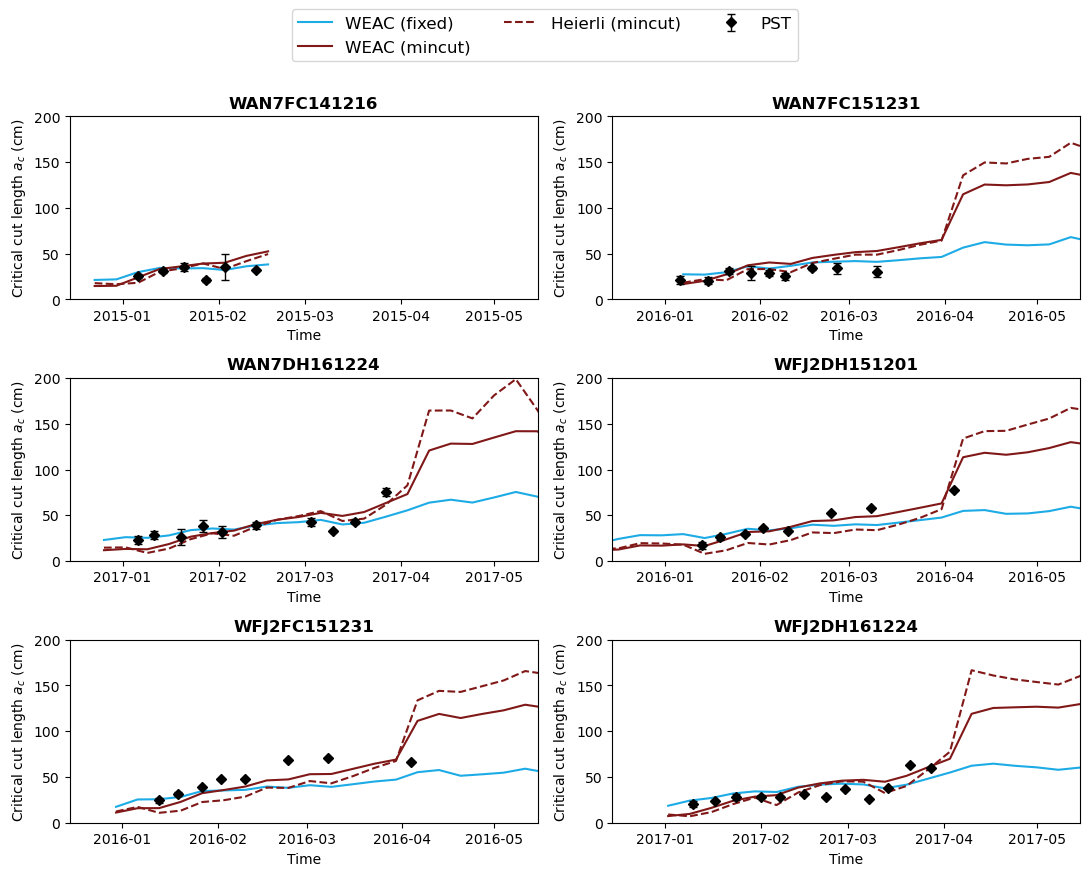

In [ ]:
COLORS = ["#1dabe6", "#801818", "#e49b30", "#006c00"]
MODE_STYLES = {mode: COLORS[i] for i, mode in enumerate(WF_MODES)}

fig = plt.figure(figsize=(11, 8))
sites = list(start_date.keys())
layers = list(start_date[sites[0]].keys())

for it, (site, layer) in enumerate([(s, l) for s in sites for l in start_date[s]], start=1):
    ax = fig.add_subplot(len(layers), len(sites), it)

    for WF_MODE in WF_MODES:
        color = MODE_STYLES[WF_MODE]
        ac_mod = results[WF_MODE]["ac_W"][site][layer]
        ax.plot(ac_mod.time, ac_mod, label=f"WEAC ({WF_MODE})", color=color, lw=1.5)

    WF_MODE = "mincut"
    ac_mod_h = results[WF_MODE]["ac_H"][site][layer]
    if not ac_mod_h.isnull().all():
        ax.plot(ac_mod_h.time, ac_mod_h, label=f"Heierli ({WF_MODE})", color=color, lw=1.5, linestyle="--")

    ac_mes_mean = ds_PST[site][layer]["ac"].groupby("time").mean()
    ac_mes_std = ds_PST[site][layer]["ac"].groupby("time").std().fillna(0)

    times = pd.to_datetime(ac_mes_mean.time.values)

    ax.errorbar(times, ac_mes_mean.values, yerr=ac_mes_std.values, fmt="D", ms=5, color="k", ecolor="k", elinewidth=1, capsize=3, label="PST", zorder=5)

    ref_time = results[WF_MODES[0]]["ac_W"][site][layer].time
    year = int(ref_time[-1].dt.year.values)
    ax.set_xlim(pd.to_datetime(f"{year - 1}-12-15"), pd.to_datetime(f"{year}-05-15"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.set_ylim(0, 200)
    ax.set_title(f"{site}{layer}", fontweight="bold")
    ax.set_ylabel(r"Critical cut length $a_c$ (cm)")
    ax.set_xlabel("Time")

plt.tight_layout()
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.25, 0.60, 0.5, 0.5), ncol=3, fontsize="large", fancybox=True, frameon=True)


plt.savefig(output_path + "Time_series_AC_measured_vs_modeled_slope_" + str(inclination) + ".pdf", dpi=300, bbox_inches="tight")

## AC at manual profiles (Crocus and OBS) : Results 3.2

In [40]:
WF_MODES = ["fixed", "density", "mincut"]
WF_FIXED = 0.15
inclination = 0
touchdown = False
E_FORMULATION = ("Bergfeld (2023)", lambda rho: 6.5e9 * (rho / RHO_ICE) ** 4.4)
H_ASSUMPTION = ("fixed", 30e-3)

e_name, e_func = E_FORMULATION
h_name, h_val = H_ASSUMPTION

POPT_MAP = {
    "density": float(popt_rhowl_crocus),
    "Strength_Gaume": float(popt_gaume_crocus),
}


def get_popt(mode):
    return POPT_MAP.get(mode, float(np.mean([popt_crocus_range["lower"], popt_crocus_range["upper"]])))


def get_wf(rho_wl, sph, ssa, mode, popt):
    if mode == "fixed":
        return WF_FIXED
    if mode == "density":
        return float(f_wf_mincut(rho_wl, popt))
    return float(np.maximum(0, f_wf_mincut(f_mincut_param(rho_wl / 917, sph, ssa), popt)))


def invert_ac_weac(rho, dz, rho_wl, h, E, wf_target, e_method_slab, bounds=(0.01, 1500), inclination=inclination, touchdown=touchdown):
    def f(ac):
        _, G = compute_wf_weac(
            rho=rho,
            dz=dz * 1000,
            rho_wl=rho_wl,
            ac=[ac],
            E_method_slab=e_method_slab,
            h_wl=h * 1000,
            E_wl=E / 1e6,
            inclination=inclination,
            touchdown=touchdown,
        )
        return float(G[0, 0]) - wf_target

    try:
        lo, hi = bounds
        return np.nan if f(lo) * f(hi) > 0 else brentq(f, lo, hi) / 10
    except Exception:
        return np.nan


def compute_ac_profile(profile_i, WL_charact_i, wf_mode, popt, manual=False, grain_intervals=None):
    rho = profile_i["RSN_VEG"].values
    dz = profile_i["SNOWDZ"].values
    if len(rho) == 0:
        return np.nan, np.nan

    rho_wl = float(WL_charact_i["RSN_VEG"])
    h = h_val if h_val is not None else float(WL_charact_i["SNOWDZ"])
    E = e_func(np.array([rho_wl]))[0]
    needs_shape = wf_mode in ("mincut", "Strength_Gaume")

    if manual:
        dict_conv = {1: "PP", 2: "DF", 3: "RG", 4: "FC", 5: "DH", 6: "DH", 7: "MF", 8: "MF", 9: "FCxr", 10: "MFcr"}
        grain_key = dict_conv[int(WL_charact_i["grain_type"].values)][:2]
        sph = np.mean(grain_intervals.loc[grain_key]["S"])
        ssa = np.mean(grain_intervals.loc[grain_key]["G"])
    else:
        sph = float(WL_charact_i["SNOWSPHER"]) if needs_shape else np.nan
        ssa = float(WL_charact_i["SNOWSSA"]) if needs_shape else np.nan

    if wf_mode == "Strength_Gaume":
        Hslab = float(np.sum(dz))
        Rho_slab = float(np.sum(rho * dz) / Hslab)
        zib = (np.cumsum(dz[::-1])[::-1] - dz - Hslab / 2) * (-1)
        zit = (np.cumsum(dz[::-1])[::-1] - Hslab / 2) * (-1)
        Eslab = float(4 * np.sum(e_func(rho) * (zib**3 - zit**3)) / Hslab**3)
        mincut_val = float(f_mincut_param(rho_wl / 917, sph, ssa))
        return float(f_rc_gaume(popt, Eslab, Hslab, Rho_slab, mincut_val)), np.nan
    else:
        wf = get_wf(
            rho_wl=rho_wl,
            sph=sph,
            ssa=ssa,
            mode=wf_mode,
            popt=popt,
        )
        ac_w = invert_ac_weac(rho, dz, rho_wl, h, E, wf, e_method_slab="bergfeld", inclination=inclination, touchdown=touchdown)
        ac_h = compute_ac_heierli_from_profile(rho=rho, dz=dz, wf=wf, E_formula=e_func, inclination=inclination) * 100
        return ac_w, ac_h


results_obs = {}
results_crocus = {}
ds_manual = {site: ds_manual_complete[site].groupby("time").mean() for site in start_date}

for wf_mode in WF_MODES:
    popt = get_popt(wf_mode)
    ac_W_Obs = {site: {} for site in start_date}
    ac_H_Obs = {site: {} for site in start_date}
    ac_W_Crocus = {site: {} for site in start_date}
    ac_H_Crocus = {site: {} for site in start_date}

    for site in start_date:
        for time in np.unique(ds_manual[site].time):
            time_str = pd.to_datetime(time).strftime("%Y%m%d")
            strati = ds_manual[site].sel(time=time_str).dropna(dim="depth", how="all")
            ls_w, ls_h = [], []
            for j in range(1, len(strati.depth)):
                ac_w, ac_h = compute_ac_profile(
                    profile_i=strati[["RSN_VEG", "SNOWDZ"]].isel(depth=slice(0, j)),
                    WL_charact_i=strati[["RSN_VEG", "SNOWDZ", "grain_type"]].isel(depth=j),
                    wf_mode=wf_mode,
                    popt=popt,
                    manual=True,
                    grain_intervals=grain_intervals,
                )
                ls_w.append(ac_w)
                ls_h.append(ac_h)
            ac_W_Obs[site][time_str] = xr.DataArray(ls_w, dims=["depth"], coords={"depth": strati.depth[1:]})
            ac_H_Obs[site][time_str] = xr.DataArray(ls_h, dims=["depth"], coords={"depth": strati.depth[1:]})

        for time in np.unique(ds_manual_complete[site].time):
            time_str = pd.to_datetime(time).strftime("%Y%m%d")
            strati = ds[site].sel(time=time_str + "T12")[["RSN_VEG", "SNOWDZ", "SNOWSPHER", "SNOWSSA"]].dropna(dim="snow_layer", how="all")
            ls_w, ls_h = [], []
            for j in range(1, len(strati.snow_layer)):
                ac_w, ac_h = compute_ac_profile(
                    profile_i=strati[["RSN_VEG", "SNOWDZ"]].isel(snow_layer=slice(0, j)),
                    WL_charact_i=strati[["RSN_VEG", "SNOWDZ", "SNOWSPHER", "SNOWSSA"]].isel(snow_layer=j),
                    wf_mode=wf_mode,
                    popt=popt,
                    manual=False,
                )
                ls_w.append(ac_w)
                ls_h.append(ac_h)
            ac_W_Crocus[site][time_str] = xr.DataArray(ls_w, dims=["snow_layer"], coords={"snow_layer": strati.snow_layer[1:]})
            ac_H_Crocus[site][time_str] = xr.DataArray(ls_h, dims=["snow_layer"], coords={"snow_layer": strati.snow_layer[1:]})

    results_obs[wf_mode] = {"ac_W": ac_W_Obs, "ac_H": ac_H_Obs}
    results_crocus[wf_mode] = {"ac_W": ac_W_Crocus, "ac_H": ac_H_Crocus}

### Selected profiles

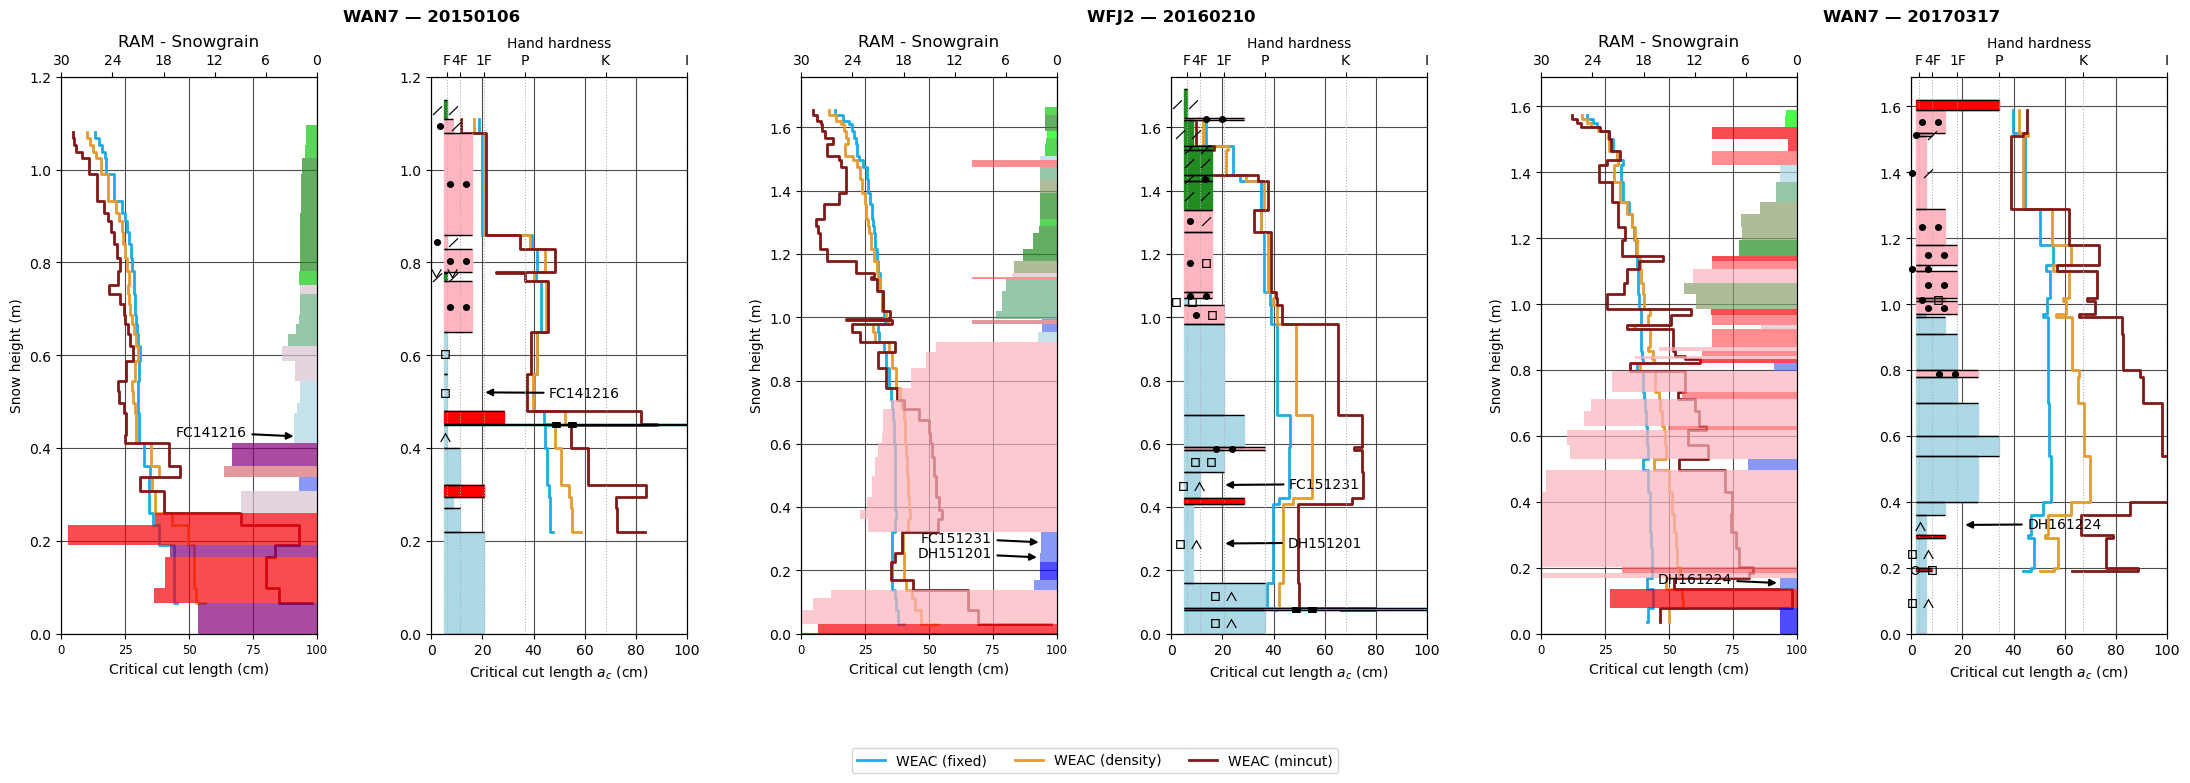

In [42]:
selected_time = {"WAN7-2015": ["20150106"], "WFJ2-2016": ["20160210"], "WAN7-2017": ["20170317"]}

COLORS = ["#1dabe6", "#e49b30", "#801818", "#006c00"]
MODE_STYLES = {mode: COLORS[i] for i, mode in enumerate(WF_MODES)}

fig, axes = plt.subplots(1, len(selected_time) * 2, figsize=(22, 7))
col = 0

for site_key, times in selected_time.items():
    site = site_key[:4]
    for time in times:
        # ── Crocus profile ───────────────────────────────────────────────
        ax = axes[col]
        ax2 = ax.twiny()
        col += 1

        ds_i = ds[site].sel(time=time + "T12", method="nearest")
        ds_i["snow_layer"] = np.arange(0, 50, 1)
        ylim = np.round(np.sum(ds_i["SNOWDZ"]), 2) + 0.1
        depth_cumsum = np.cumsum(ds_i["SNOWDZ"][::-1])[::-1]

        dateProfil(ax, ax2, value=ds_i["RSN_VEG"] * 100, value_dz=ds_i["SNOWDZ"].fillna(0).values, value_grain=ds_i["SNOWTYPE"].values, value_ram=ds_i["SNOWRAM"].values, color="green")

        # ── Crocus profile ───────────────────────────────────────────────
        for wf_mode in WF_MODES:
            color = MODE_STYLES[wf_mode]
            ac_w = results_crocus[wf_mode]["ac_W"][site][time].reindex_like(ds_i["RSN_VEG"])
            label_w = f"{'Gaume' if wf_mode == 'Strength_Gaume' else 'WEAC'} ({wf_mode})"
            mask_w = ~np.isnan(ac_w.values)
            ax.step(ac_w.values[mask_w], depth_cumsum[mask_w], color=color, lw=2, where="pre", label=label_w)

        ac_h = results_crocus["mincut"]["ac_H"][site][time].reindex_like(ds_i["RSN_VEG"])
        # if not ac_h.isnull().all():
        #     mask_h = ~np.isnan(ac_h.values)
        #     ax.step(ac_h.values[mask_h], depth_cumsum[mask_h], color=color, lw=2, where="pre", ls="--", label=f"Heierli ({'mincut'})")

        for layer in start_date[site]:
            if pd.to_datetime(time) not in ds_PST[site][layer].time:
                continue
            wl_t = ds_layer[site][layer].sel(time=time, method="nearest")
            x = float(wl_t["SNOWRAM"].mean())
            ytop = float(wl_t["top_depth"].mean())
            y = ytop - float(wl_t["SNOWDZ"].mean()) / 2
            ax2.annotate(layer, xy=(x, y), xytext=(x + 10, y), ha="center", arrowprops=dict(arrowstyle="-|>", color="k", lw=1.5))

        ax.set(xlim=(0, 100), ylim=(0, ylim), xlabel="Critical cut length (cm)", ylabel="Snow height (m)")
        ax.grid(True, color="k", alpha=0.7)

        # ── Manual profile ───────────────────────────────────────────────
        ax = axes[col]
        ax2 = ax.twiny()
        col += 1

        strati = ds_manual_complete[site].drop_duplicates(dim="time").sortby("time").sel(time=time, method="nearest").dropna(dim="depth", how="all")

        # ── Manual profile ───────────────────────────────────────────────
        for wf_mode in WF_MODES:
            color = MODE_STYLES[wf_mode]
            ac_w = results_obs[wf_mode]["ac_W"][site][time]
            label_w = f"{'Gaume' if wf_mode == 'Strength_Gaume' else 'WEAC'} ({wf_mode})"
            ax.step(ac_w, ac_w.depth, color=color, lw=2, where="pre", label=label_w)
        # ac_h = results_obs["mincut"]["ac_H"][site][time]
        # if not ac_h.isnull().all():
        #     ax.step(ac_h, ac_h.depth, color=color, lw=2, where="pre", ls="--", label=f"Heierli ({'mincut'})")

        snowprofile.plot.plot_utils.plot_strati_profile(
            ax2,
            snowprofile.profiles.Stratigraphy(
                data={
                    "grain_1": strati["grain_type1"],
                    "grain_2": strati["grain_type2"],
                    "top_height": strati["depth"],
                    "thickness": strati["SNOWDZ"],
                    "hardness": strati["hand_hardness"],
                    "grain_size": None,
                    "wetness": None,
                }
            ),
            xlabel="Hand hardness",
            ylabel="Height (m)",
            grain_labels=True,
            use_hardness=True,
        )

        for layer in start_date[site]:
            if pd.to_datetime(time) not in ds_PST[site][layer].time:
                continue
            ytop = ds_PST[site][layer]["depth"].drop_duplicates("time").sel(time=time, method="nearest").values.mean() / 100
            idx = int((np.abs(strati["depth"] - ytop)).argmin())
            y = float(strati["depth"][idx]) - float(strati["SNOWDZ"][idx]) / 2
            ax.annotate(layer, xy=(20, y), xytext=(60, y - 0.01), ha="center", arrowprops=dict(arrowstyle="-|>", color="k", lw=1.5))

        ax.set(xlim=(0, 100), ylim=(0, ylim), xlabel=r"Critical cut length $a_c$ (cm)")
        ax2.set_ylim(0, ylim)
        ax.grid(True, color="k", alpha=0.7)
        ax.text(x=0, y=1.10, s=f"{site} — {time}", fontweight="bold", fontsize=12, transform=ax.transAxes, ha="center")

legend_handles = []
for wf_mode in WF_MODES:
    color = MODE_STYLES[wf_mode]
    label_w = f"{'Gaume' if wf_mode == 'Strength_Gaume' else 'WEAC'} ({wf_mode})"
    legend_handles.append(Line2D([0], [0], color=color, lw=2, linestyle="-", label=label_w))
# legend_handles.append(Line2D([0], [0], color=color, lw=2, linestyle="--", label=f"Heierli ({'mincut'})"))


plt.tight_layout()
fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.12), ncol=len(WF_MODES), fontsize="medium", fancybox=True, frameon=True)

# plt.show()
plt.savefig(output_path + "Selected_profiles_review.pdf", bbox_inches="tight")
